In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/025_01.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/001_01.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/006_04.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/052_04.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/072_07.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/051_04.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/028_07.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/003_13.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/038_01.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/047_06.bmp
/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5/normal_Parabasal/055_01.bmp
/kaggle/input/datasets/akshaykrishnan/sipak

In [2]:
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = "/kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5"
OUTPUT_DIR = "/kaggle/working/ablation_no_global_node_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = [
    "abnormal_Dyskeratotic",
    "abnormal_Koilocytotic",
    "benign_Metaplastic",
    "normal_Parabasal",
    "normal_Superficial_Intermediate",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_FOLDS = 5
EPOCHS = 14
BACKBONE_LR = 8e-5
HEAD_LR = 4e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
USE_AMP = torch.cuda.is_available()
PATIENCE = 4
LABEL_SMOOTHING = 0.05

print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)

Device: cuda
Output dir: /kaggle/working/ablation_no_global_node_results


In [4]:
def find_dataset_root():
    if os.path.isdir(DATASET_ROOT):
        return DATASET_ROOT
    for root, dirs, files in os.walk("/kaggle/input"):
        if all(cls in dirs for cls in CLASS_NAMES):
            return root
    raise FileNotFoundError("Could not find SIPaKMeD dataset root in /kaggle/input")


DATASET_ROOT = find_dataset_root()
print("Dataset root:", DATASET_ROOT)
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_ROOT, cls)
    print(cls, "->", len(os.listdir(cls_dir)))

Dataset root: /kaggle/input/datasets/akshaykrishnan/sipakmed5/sipakmed_5
abnormal_Dyskeratotic -> 813
abnormal_Koilocytotic -> 825
benign_Metaplastic -> 793
normal_Parabasal -> 787
normal_Superficial_Intermediate -> 831


In [5]:
def collect_samples(root):
    valid_ext = (".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff")
    samples = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(root, cls)
        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(valid_ext):
                samples.append((os.path.join(cls_dir, fname), CLASS_TO_IDX[cls]))
    return samples


samples = collect_samples(DATASET_ROOT)
paths = [x[0] for x in samples]
labels = np.array([x[1] for x in samples])

print("Total images:", len(samples))
print("Class counts:")
for cls in CLASS_NAMES:
    count = sum(1 for _, y in samples if y == CLASS_TO_IDX[cls])
    print(cls, count)

Total images: 4049
Class counts:
abnormal_Dyskeratotic 813
abnormal_Koilocytotic 825
benign_Metaplastic 793
normal_Parabasal 787
normal_Superficial_Intermediate 831


In [6]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(
        brightness=0.10, contrast=0.10, saturation=0.08, hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


class CytologyDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label, path

In [7]:
def build_region_nodes(feature_map):
    # feature_map: [B, C, H, W]
    b, c, h, w = feature_map.shape
    h2, w2 = h // 2, w // 2

    tl = F.adaptive_avg_pool2d(
        feature_map[:, :, :h2, :w2], 1
    ).flatten(1)
    tr = F.adaptive_avg_pool2d(
        feature_map[:, :, :h2, w2:], 1
    ).flatten(1)
    bl = F.adaptive_avg_pool2d(
        feature_map[:, :, h2:, :w2], 1
    ).flatten(1)
    br = F.adaptive_avg_pool2d(
        feature_map[:, :, h2:, w2:], 1
    ).flatten(1)

    # No-global-node ablation:
    # retain only the four local spatial-region descriptors.
    nodes = torch.stack([tl, tr, bl, br], dim=1)
    return nodes


In [8]:
class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.2, alpha=0.2):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.attn = nn.Linear(2 * out_dim, 1, bias=False)
        self.leakyrelu = nn.LeakyReLU(alpha)
        self.dropout = nn.Dropout(dropout)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, x, adj):
        # x: [B, N, D]
        b, n, _ = x.shape
        h = self.W(x)  # [B, N, out_dim]

        # Pairwise concatenation of node features
        h_i = h.unsqueeze(2).repeat(1, 1, n, 1)  # [B, N, N, out_dim]
        h_j = h.unsqueeze(1).repeat(1, n, 1, 1)  # [B, N, N, out_dim]
        e = self.leakyrelu(
            self.attn(torch.cat([h_i, h_j], dim=-1)).squeeze(-1)
        )  # [B, N, N]

        # Mask non-edges
        mask = (adj > 0).unsqueeze(0).expand(b, -1, -1)
        e = e.masked_fill(~mask, float("-inf"))

        alpha = F.softmax(e, dim=-1)  # attention over neighbours
        alpha = self.dropout(alpha)
        out = torch.bmm(alpha, h)  # [B, N, out_dim]

        # BN + activation
        out = out.reshape(b * n, -1)
        out = self.bn(out)
        out = out.reshape(b, n, -1)
        out = F.elu(out)
        return self.dropout(out)

In [9]:
class FuzzyConfidenceDecisionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale_conf = nn.Parameter(torch.tensor(1.0))
        self.scale_sep = nn.Parameter(torch.tensor(1.0))

    def forward(self, logits):
        probs = F.softmax(logits, dim=1)
        mu_c = probs

        top2 = torch.topk(probs, k=2, dim=1).values
        margin = (top2[:, 0] - top2[:, 1]).unsqueeze(1)
        mu_s = torch.clamp(probs + margin, 0.0, 1.0)

        fuzzy_score = (self.scale_conf * mu_c) * (self.scale_sep * mu_s)
        pred = torch.argmax(fuzzy_score, dim=1)
        return probs, mu_c, mu_s, fuzzy_score, pred

In [10]:
class EnhancedCNNGATFuzzyModel(nn.Module):
    def __init__(self, num_classes=5, node_dim=160, gat_dim=160):
        super().__init__()
        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.backbone = backbone.features
        self.proj = nn.Conv2d(1280, node_dim, kernel_size=1)

        self.gat1 = GraphAttentionLayer(node_dim, gat_dim, dropout=0.2)
        self.gat2 = GraphAttentionLayer(gat_dim, gat_dim, dropout=0.2)

        self.mlp = nn.Sequential(
            nn.Linear(gat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes),
        )
        self.fuzzy_head = FuzzyConfidenceDecisionHead()

        # No-global-node ablation:
        # 4-node adjacency containing only the local regions.
        adj = torch.tensor([
            [1, 1, 1, 0],
            [1, 1, 0, 1],
            [1, 0, 1, 1],
            [0, 1, 1, 1],
        ], dtype=torch.float32)
        self.register_buffer("adj", adj)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.proj(feat)
        nodes = build_region_nodes(feat)
        g = self.gat1(nodes, self.adj)
        g = self.gat2(g, self.adj)
        pooled = g.mean(dim=1)
        logits = self.mlp(pooled)
        probs, mu_c, mu_s, fuzzy_score, pred = self.fuzzy_head(logits)
        return {
            "logits": logits,
            "probs": probs,
            "mu_c": mu_c,
            "mu_s": mu_s,
            "fuzzy_score": fuzzy_score,
            "pred": pred,
        }

In [11]:
def make_loaders(train_items, val_items):
    train_ds = CytologyDataset(train_items, train_tfms)
    val_ds = CytologyDataset(val_items, val_tfms)
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    return train_loader, val_loader


def make_model():
    model = EnhancedCNNGATFuzzyModel(num_classes=len(CLASS_NAMES)).to(DEVICE)
    backbone_params = list(model.backbone.parameters())
    other_params = [
        p for n, p in model.named_parameters()
        if not n.startswith("backbone.")
    ]
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": other_params, "lr": HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    return model, optimizer, scheduler, scaler

In [12]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []

    for step, (images, labels, _) in enumerate(loader, start=1):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out = model(images)
            loss_ce = F.cross_entropy(
                out["logits"], labels, label_smoothing=LABEL_SMOOTHING
            )
            true_fuzzy = out["fuzzy_score"].gather(
                1, labels.unsqueeze(1)
            ).mean()
            loss = loss_ce - 0.1 * true_fuzzy

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(out["pred"].detach().cpu().numpy().tolist())

        if step % 10 == 0 or step == len(loader):
            print(f"    Train iter {step}/{len(loader)} | batch_loss={loss.item():.4f}")

    acc = accuracy_score(y_true, y_pred)
    return total_loss / len(loader.dataset), acc


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    for step, (images, labels, _) in enumerate(loader, start=1):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        out = model(images)
        loss_ce = F.cross_entropy(
            out["logits"], labels, label_smoothing=LABEL_SMOOTHING
        )
        true_fuzzy = out["fuzzy_score"].gather(
            1, labels.unsqueeze(1)
        ).mean()
        loss = loss_ce - 0.1 * true_fuzzy
        total_loss += loss.item() * images.size(0)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(out["pred"].cpu().numpy().tolist())

        if step % 10 == 0 or step == len(loader):
            print(f"    Val   iter {step}/{len(loader)} | batch_loss={loss.item():.4f}")

    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return total_loss / len(loader.dataset), acc, pr, rc, f1, y_true, y_pred

In [13]:
all_fold_metrics = []
all_reports = []
all_history = []

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(paths, labels), start=1):
    print("=" * 90)
    print(f"FOLD {fold}/{NUM_FOLDS}")
    print("=" * 90)

    train_items = [samples[i] for i in tr_idx]
    val_items = [samples[i] for i in va_idx]
    train_loader, val_loader = make_loaders(train_items, val_items)
    model, optimizer, scheduler, scaler = make_model()

    best_state = None
    best_val_acc = -1.0
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scaler)
        va_loss, va_acc, va_pr, va_rc, va_f1, y_true, y_pred = evaluate(
            model, val_loader
        )
        scheduler.step(va_acc)

        all_history.append({
            "fold": fold,
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "val_precision_macro": va_pr,
            "val_recall_macro": va_rc,
            "val_f1_macro": va_f1,
        })

        print(
            f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | train_acc={tr_acc:.4f} "
            f"| val_loss={va_loss:.4f} | val_acc={va_acc:.4f} | val_f1={va_f1:.4f}"
        )

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    va_loss, va_acc, va_pr, va_rc, va_f1, y_true, y_pred = evaluate(
        model, val_loader
    )

    fold_metrics = {
        "fold": fold,
        "best_epoch": best_epoch,
        "accuracy": va_acc,
        "precision_macro": va_pr,
        "recall_macro": va_rc,
        "f1_macro": va_f1,
        "n_train": len(train_items),
        "n_val": len(val_items),
    }
    all_fold_metrics.append(fold_metrics)

    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES,
        digits=4, zero_division=0
    )
    all_reports.append(f"FOLD {fold}\n{report}\n")
    print("\n" + report)

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        os.path.join(OUTPUT_DIR, f"confusion_matrix_fold_{fold}.csv")
    )
    torch.save(best_state, os.path.join(OUTPUT_DIR, f"best_model_fold_{fold}.pt"))

FOLD 1/5
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s] 


    Train iter 10/203 | batch_loss=1.3979
    Train iter 20/203 | batch_loss=1.2393
    Train iter 30/203 | batch_loss=0.7634
    Train iter 40/203 | batch_loss=0.6435
    Train iter 50/203 | batch_loss=0.7932
    Train iter 60/203 | batch_loss=0.4833
    Train iter 70/203 | batch_loss=0.5341
    Train iter 80/203 | batch_loss=0.4056
    Train iter 90/203 | batch_loss=0.6080
    Train iter 100/203 | batch_loss=0.3645
    Train iter 110/203 | batch_loss=0.3188
    Train iter 120/203 | batch_loss=0.4962
    Train iter 130/203 | batch_loss=0.4919
    Train iter 140/203 | batch_loss=0.7456
    Train iter 150/203 | batch_loss=0.3914
    Train iter 160/203 | batch_loss=0.4215
    Train iter 170/203 | batch_loss=0.6332
    Train iter 180/203 | batch_loss=0.7946
    Train iter 190/203 | batch_loss=0.9128
    Train iter 200/203 | batch_loss=0.5619
    Train iter 203/203 | batch_loss=0.8294
    Val   iter 10/51 | batch_loss=0.2853
    Val   iter 20/51 | batch_loss=1.0035
    Val   iter 30/51 | b

In [14]:
fold_df = pd.DataFrame(all_fold_metrics)
history_df = pd.DataFrame(all_history)
summary_df = pd.DataFrame([{
    "accuracy_mean": fold_df["accuracy"].mean(),
    "accuracy_std": fold_df["accuracy"].std(ddof=0),
    "precision_macro_mean": fold_df["precision_macro"].mean(),
    "recall_macro_mean": fold_df["recall_macro"].mean(),
    "f1_macro_mean": fold_df["f1_macro"].mean(),
}])

fold_df.to_csv(os.path.join(OUTPUT_DIR, "fold_metrics.csv"), index=False)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "classification_reports.txt"), "w") as f:
    f.write("\n".join(all_reports))

print("\nFinal fold metrics")
print(fold_df)
print("\nSummary metrics")
print(summary_df)
print("\nSaved files in:", OUTPUT_DIR)


Final fold metrics
   fold  best_epoch  accuracy  precision_macro  recall_macro  f1_macro  \
0     1           4  0.966667         0.966863      0.966694  0.966771   
1     2          11  0.980247         0.980595      0.980233  0.980329   
2     3          11  0.974074         0.974313      0.974354  0.974047   
3     4          13  0.977778         0.978094      0.977980  0.977991   
4     5           9  0.972806         0.972865      0.973091  0.972876   

   n_train  n_val  
0     3239    810  
1     3239    810  
2     3239    810  
3     3239    810  
4     3240    809  

Summary metrics
   accuracy_mean  accuracy_std  precision_macro_mean  recall_macro_mean  \
0       0.974314      0.004648              0.974546           0.974471   

   f1_macro_mean  
0       0.974403  

Saved files in: /kaggle/working/ablation_no_global_node_results


In [15]:
print(
    "Ablation Architecture: Cytology Input -> EfficientNet-B0 -> Region-to-Graph (4 local nodes, no global node) "
    "-> 2x GAT -> Graph Pooling -> MLP -> Fuzzy Confidence Decision Head -> Final Prediction"
)

Ablation Architecture: Cytology Input -> EfficientNet-B0 -> Region-to-Graph (4 local nodes, no global node) -> 2x GAT -> Graph Pooling -> MLP -> Fuzzy Confidence Decision Head -> Final Prediction


Generating actual predictions: Fold 1/5
Generating actual predictions: Fold 2/5
Generating actual predictions: Fold 3/5
Generating actual predictions: Fold 4/5
Generating actual predictions: Fold 5/5

ACTUAL OUT-OF-FOLD RESULTS
Total images: 4049
Correct predictions: 3945
Incorrect predictions: 104
Accuracy: 97.43%


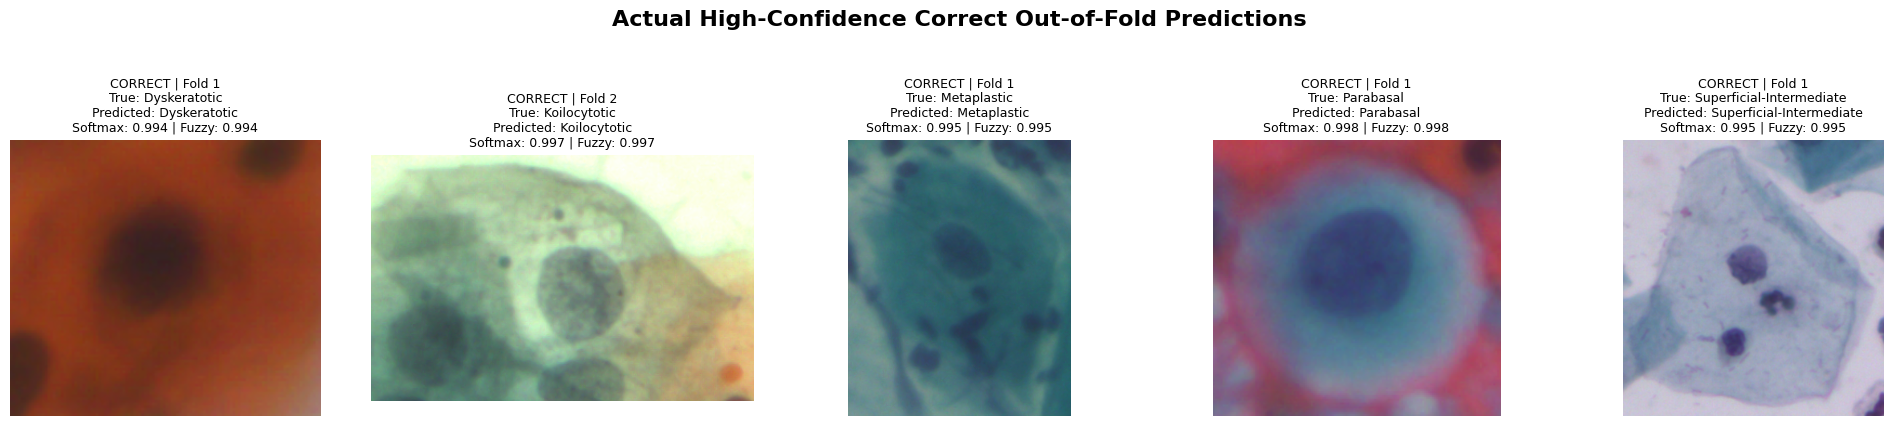

Saved: /kaggle/working/ablation_no_global_node_results/actual_qualitative_results/actual_high_confidence_correct_predictions.png


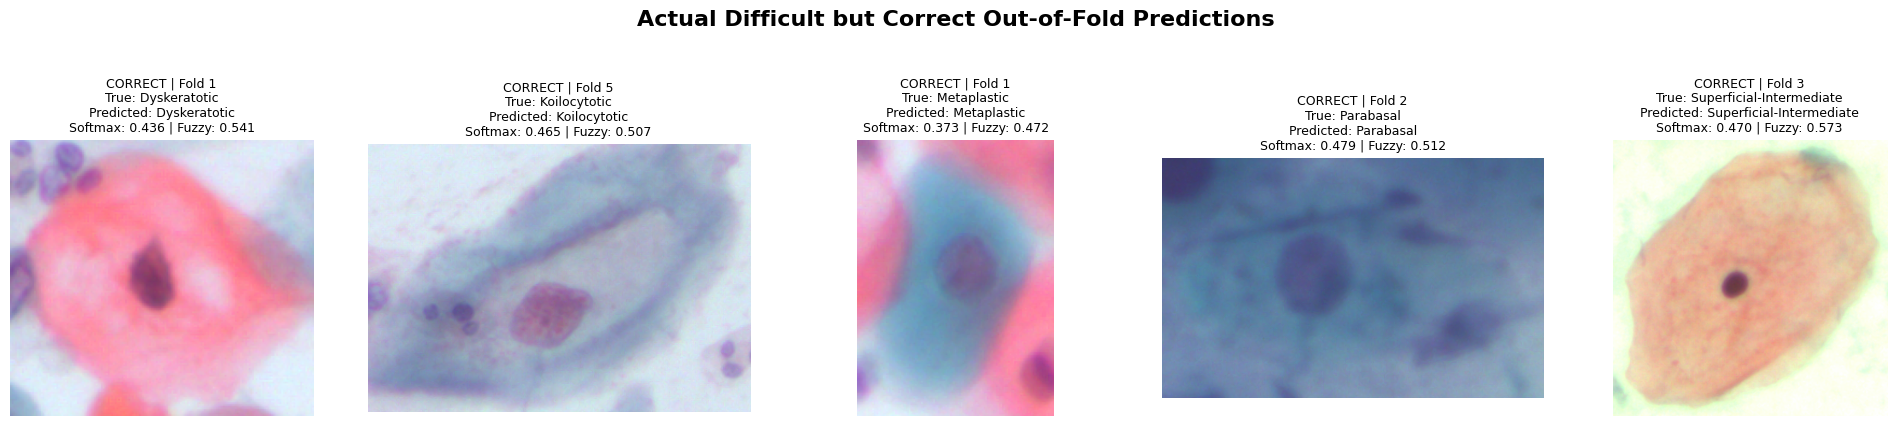

Saved: /kaggle/working/ablation_no_global_node_results/actual_qualitative_results/actual_difficult_correct_predictions.png


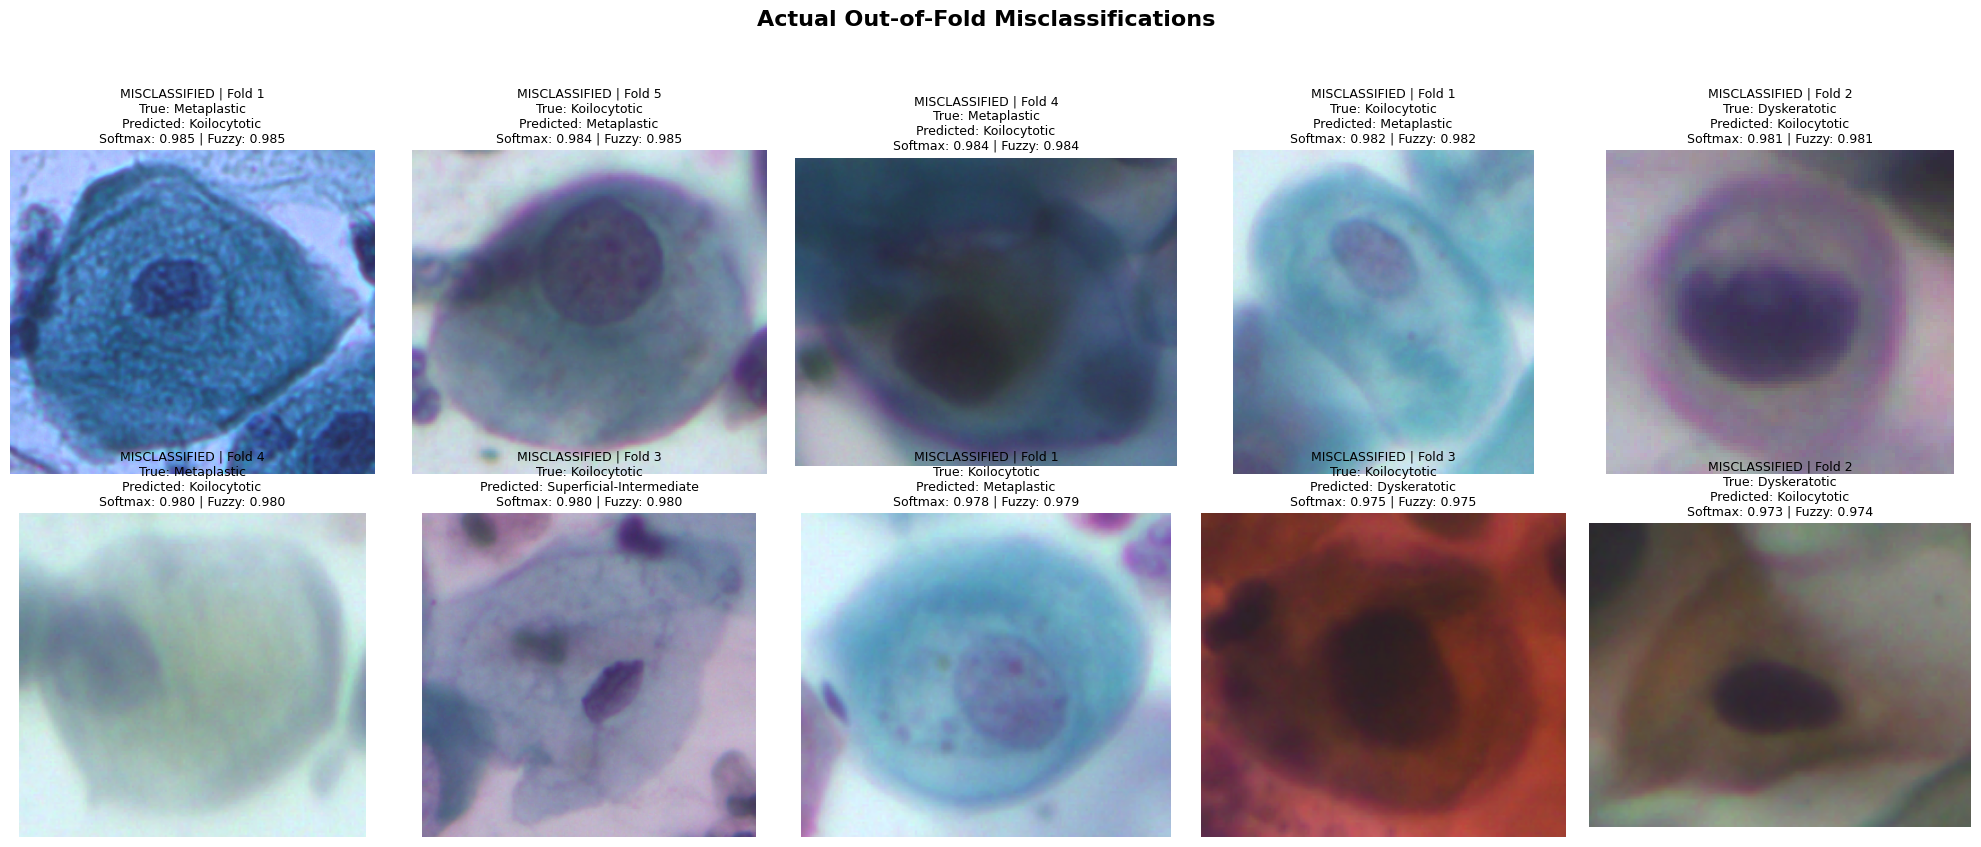

Saved: /kaggle/working/ablation_no_global_node_results/actual_qualitative_results/actual_misclassifications.png


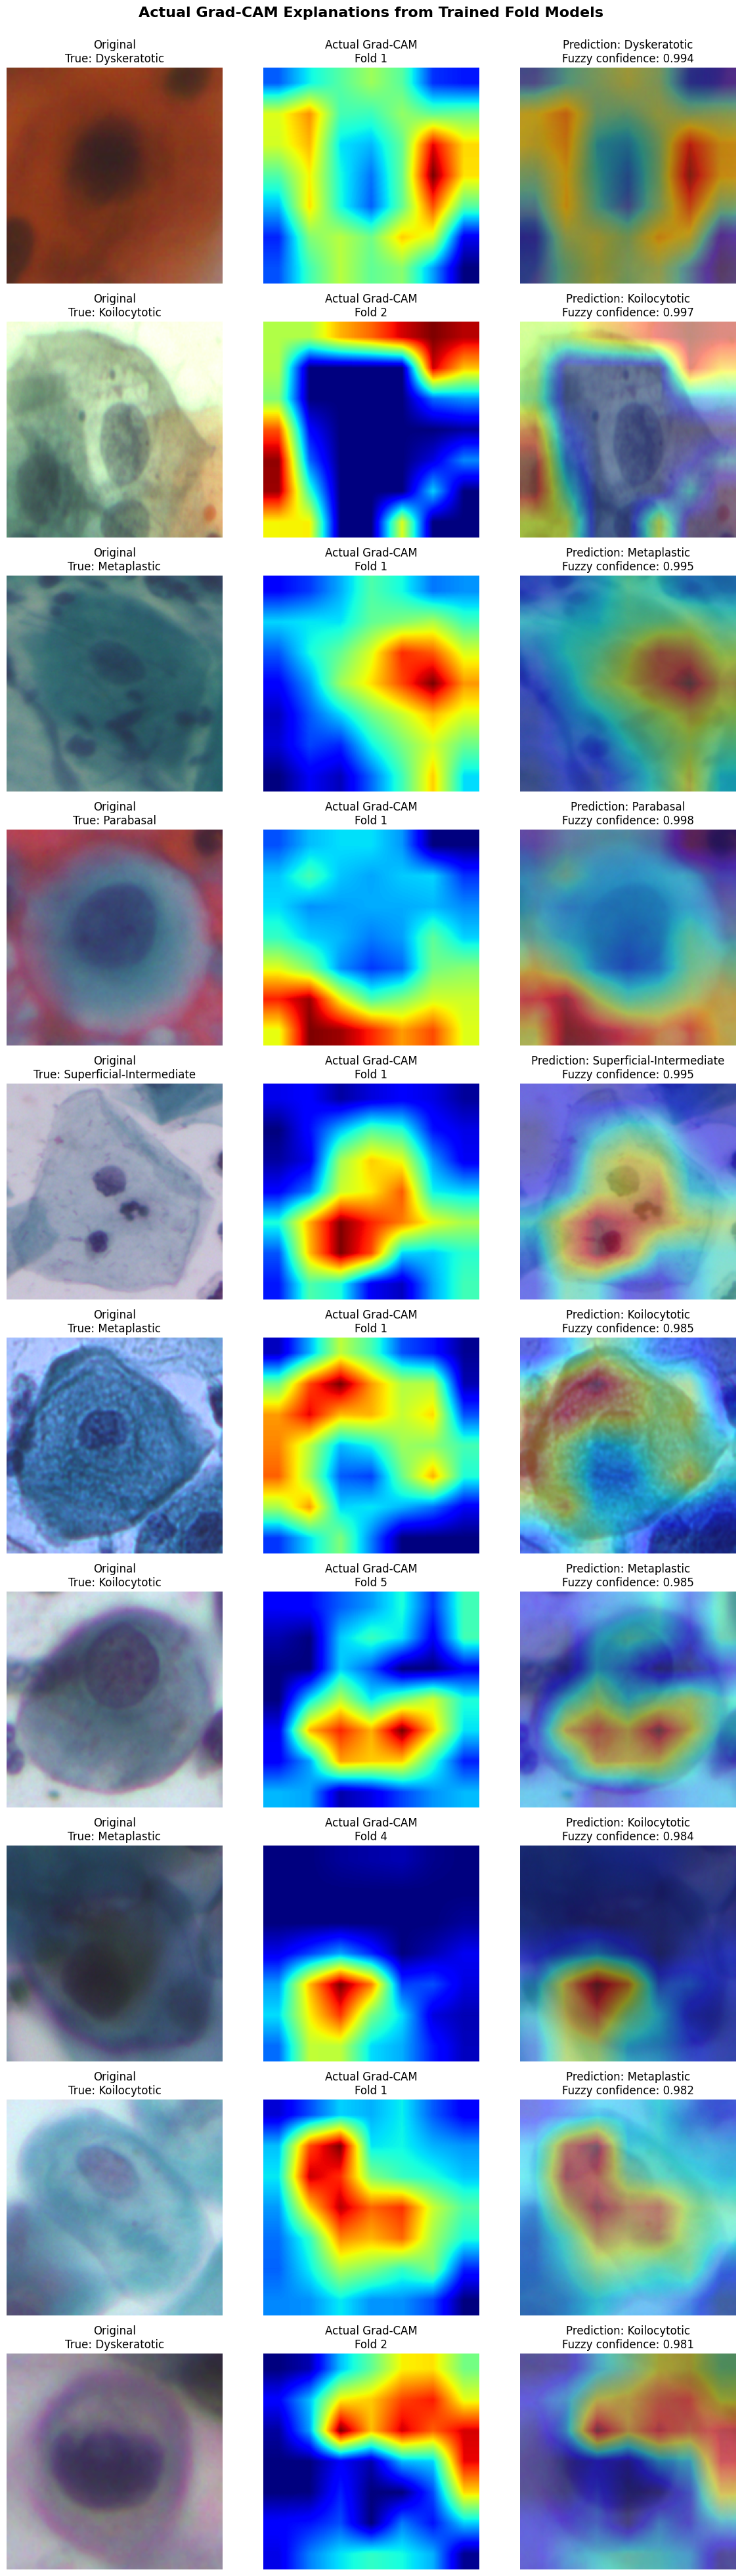

Saved: /kaggle/working/ablation_no_global_node_results/actual_qualitative_results/actual_gradcam_results.png

All actual qualitative results are saved in:
/kaggle/working/ablation_no_global_node_results/actual_qualitative_results

Generated files:
 - actual_difficult_correct_predictions.png
 - actual_gradcam_results.png
 - actual_high_confidence_correct_predictions.png
 - actual_misclassifications.png
 - actual_out_of_fold_predictions.csv


In [16]:
# ==============================================================
# ONE CELL — ACTUAL QUALITATIVE RESULTS FROM TRAINED 5-FOLD MODELS
# Run this cell after completing the training cells.
# ==============================================================

import os
import gc
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold

QUAL_DIR = os.path.join(OUTPUT_DIR, "actual_qualitative_results")
os.makedirs(QUAL_DIR, exist_ok=True)

DISPLAY_NAMES = {
    0: "Dyskeratotic",
    1: "Koilocytotic",
    2: "Metaplastic",
    3: "Parabasal",
    4: "Superficial-Intermediate",
}


# --------------------------------------------------------------
# Load a trained fold model
# --------------------------------------------------------------
def load_fold_model(fold_number):
    checkpoint_path = os.path.join(
        OUTPUT_DIR,
        f"best_model_fold_{fold_number}.pt"
    )

    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}\n"
            "Run the model-training cells first."
        )

    fold_model = EnhancedCNNGATFuzzyModel(
        num_classes=len(CLASS_NAMES)
    ).to(DEVICE)

    try:
        state = torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True
        )
    except TypeError:
        state = torch.load(
            checkpoint_path,
            map_location=DEVICE
        )

    fold_model.load_state_dict(state, strict=True)
    fold_model.eval()
    return fold_model


# --------------------------------------------------------------
# Obtain genuine out-of-fold predictions
# --------------------------------------------------------------
all_predictions = []

qual_skf = StratifiedKFold(
    n_splits=NUM_FOLDS,
    shuffle=True,
    random_state=SEED
)

for fold, (_, validation_indices) in enumerate(
    qual_skf.split(paths, labels),
    start=1
):
    print(f"Generating actual predictions: Fold {fold}/{NUM_FOLDS}")

    validation_items = [
        samples[index] for index in validation_indices
    ]

    validation_dataset = CytologyDataset(
        validation_items,
        val_tfms
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    fold_model = load_fold_model(fold)

    with torch.inference_mode():
        for images, true_labels, image_paths in validation_loader:

            images = images.to(DEVICE)
            true_labels = true_labels.to(DEVICE)

            output = fold_model(images)

            probabilities = output["probs"]
            fuzzy_scores = output["fuzzy_score"]
            predictions = output["pred"]

            normalized_fuzzy = fuzzy_scores / fuzzy_scores.sum(
                dim=1,
                keepdim=True
            ).clamp_min(1e-12)

            top_two = torch.topk(
                normalized_fuzzy,
                k=2,
                dim=1
            ).values

            fuzzy_margin = top_two[:, 0] - top_two[:, 1]

            probabilities = probabilities.cpu().numpy()
            normalized_fuzzy = normalized_fuzzy.cpu().numpy()
            predictions = predictions.cpu().numpy()
            true_labels = true_labels.cpu().numpy()
            fuzzy_margin = fuzzy_margin.cpu().numpy()

            for i, image_path in enumerate(image_paths):

                true_index = int(true_labels[i])
                predicted_index = int(predictions[i])

                all_predictions.append({
                    "fold": fold,
                    "image_path": image_path,
                    "true_index": true_index,
                    "true_class": DISPLAY_NAMES[true_index],
                    "predicted_index": predicted_index,
                    "predicted_class": DISPLAY_NAMES[predicted_index],
                    "correct": true_index == predicted_index,
                    "softmax_confidence": float(
                        probabilities[i, predicted_index]
                    ),
                    "fuzzy_confidence": float(
                        normalized_fuzzy[i, predicted_index]
                    ),
                    "fuzzy_margin": float(fuzzy_margin[i])
                })

    del fold_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


results_df = pd.DataFrame(all_predictions)

results_csv = os.path.join(
    QUAL_DIR,
    "actual_out_of_fold_predictions.csv"
)

results_df.to_csv(results_csv, index=False)

print("\n" + "=" * 70)
print("ACTUAL OUT-OF-FOLD RESULTS")
print("=" * 70)
print("Total images:", len(results_df))
print("Correct predictions:", int(results_df["correct"].sum()))
print("Incorrect predictions:", int((~results_df["correct"]).sum()))
print(f'Accuracy: {results_df["correct"].mean() * 100:.2f}%')


# --------------------------------------------------------------
# Select actual qualitative examples
# --------------------------------------------------------------
correct_df = results_df[
    results_df["correct"]
].copy()

incorrect_df = results_df[
    ~results_df["correct"]
].copy()


# One highest-confidence correct image from every class
high_confidence_correct = (
    correct_df
    .sort_values(
        ["true_index", "fuzzy_confidence"],
        ascending=[True, False]
    )
    .groupby("true_index")
    .head(1)
    .sort_values("true_index")
    .reset_index(drop=True)
)


# One most difficult correctly classified image from every class
difficult_correct = (
    correct_df
    .sort_values(
        ["true_index", "fuzzy_confidence"],
        ascending=[True, True]
    )
    .groupby("true_index")
    .head(1)
    .sort_values("true_index")
    .reset_index(drop=True)
)


# Ten real high-confidence model errors
actual_errors = (
    incorrect_df
    .sort_values(
        ["fuzzy_confidence", "fuzzy_margin"],
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# Function for displaying and saving actual image examples
# --------------------------------------------------------------
def plot_prediction_examples(
    dataframe,
    figure_title,
    filename,
    columns=5
):
    if len(dataframe) == 0:
        print(f"No examples available for: {figure_title}")
        return

    rows = math.ceil(len(dataframe) / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(4 * columns, 4.3 * rows),
        squeeze=False
    )

    for axis in axes.ravel():
        axis.axis("off")

    for axis, (_, row) in zip(
        axes.ravel(),
        dataframe.iterrows()
    ):
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        axis.imshow(image)
        axis.axis("off")

        result_text = (
            "CORRECT" if row["correct"] else "MISCLASSIFIED"
        )

        axis.set_title(
            f'{result_text} | Fold {int(row["fold"])}\n'
            f'True: {row["true_class"]}\n'
            f'Predicted: {row["predicted_class"]}\n'
            f'Softmax: {row["softmax_confidence"]:.3f} | '
            f'Fuzzy: {row["fuzzy_confidence"]:.3f}',
            fontsize=9
        )

    fig.suptitle(
        figure_title,
        fontsize=16,
        fontweight="bold"
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    save_path = os.path.join(
        QUAL_DIR,
        filename
    )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", save_path)


plot_prediction_examples(
    high_confidence_correct,
    "Actual High-Confidence Correct Out-of-Fold Predictions",
    "actual_high_confidence_correct_predictions.png",
    columns=5
)

plot_prediction_examples(
    difficult_correct,
    "Actual Difficult but Correct Out-of-Fold Predictions",
    "actual_difficult_correct_predictions.png",
    columns=5
)

plot_prediction_examples(
    actual_errors,
    "Actual Out-of-Fold Misclassifications",
    "actual_misclassifications.png",
    columns=5
)


# --------------------------------------------------------------
# Actual Grad-CAM generation
# --------------------------------------------------------------
def create_gradcam(sample_row):

    fold_number = int(sample_row["fold"])
    gradcam_model = load_fold_model(fold_number)

    original_image = Image.open(
        sample_row["image_path"]
    ).convert("RGB")

    input_tensor = val_tfms(
        original_image
    ).unsqueeze(0).to(DEVICE)

    stored_activations = {}
    stored_gradients = {}

    target_layer = gradcam_model.backbone[-1]

    def activation_hook(module, inputs, output):
        stored_activations["value"] = output

        output.register_hook(
            lambda gradient: stored_gradients.__setitem__(
                "value",
                gradient
            )
        )

    hook = target_layer.register_forward_hook(
        activation_hook
    )

    gradcam_model.zero_grad(set_to_none=True)

    model_output = gradcam_model(input_tensor)

    predicted_class = int(
        model_output["pred"].item()
    )

    selected_logit = model_output[
        "logits"
    ][0, predicted_class]

    selected_logit.backward()

    activations = stored_activations["value"]
    gradients = stored_gradients["value"]

    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )

    gradcam = (
        weights * activations
    ).sum(dim=1, keepdim=True)

    gradcam = F.relu(gradcam)

    gradcam = F.interpolate(
        gradcam,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )

    gradcam = gradcam[0, 0]

    gradcam = gradcam - gradcam.min()
    gradcam = gradcam / gradcam.max().clamp_min(1e-12)

    gradcam_array = gradcam.detach().cpu().numpy()

    resized_image = original_image.resize(
        (IMG_SIZE, IMG_SIZE)
    )

    image_array = np.asarray(
        resized_image
    ).astype(np.float32) / 255.0

    heatmap = plt.cm.jet(
        gradcam_array
    )[:, :, :3]

    overlay = np.clip(
        0.55 * image_array + 0.45 * heatmap,
        0,
        1
    )

    hook.remove()

    del gradcam_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return image_array, gradcam_array, overlay


# Five correct examples and five actual errors
gradcam_examples = pd.concat(
    [
        high_confidence_correct.head(5),
        actual_errors.head(5)
    ],
    ignore_index=True
)


if len(gradcam_examples) > 0:

    fig, axes = plt.subplots(
        len(gradcam_examples),
        3,
        figsize=(12, 4 * len(gradcam_examples)),
        squeeze=False
    )

    for row_number, (_, sample_row) in enumerate(
        gradcam_examples.iterrows()
    ):

        original, heatmap, overlay = create_gradcam(
            sample_row
        )

        axes[row_number, 0].imshow(original)
        axes[row_number, 0].set_title(
            f'Original\nTrue: {sample_row["true_class"]}'
        )
        axes[row_number, 0].axis("off")

        axes[row_number, 1].imshow(
            heatmap,
            cmap="jet",
            vmin=0,
            vmax=1
        )
        axes[row_number, 1].set_title(
            f'Actual Grad-CAM\n'
            f'Fold {int(sample_row["fold"])}'
        )
        axes[row_number, 1].axis("off")

        axes[row_number, 2].imshow(overlay)
        axes[row_number, 2].set_title(
            f'Prediction: {sample_row["predicted_class"]}\n'
            f'Fuzzy confidence: '
            f'{sample_row["fuzzy_confidence"]:.3f}'
        )
        axes[row_number, 2].axis("off")

    fig.suptitle(
        "Actual Grad-CAM Explanations from Trained Fold Models",
        fontsize=16,
        fontweight="bold"
    )

    fig.tight_layout(
        rect=[0, 0, 1, 0.98]
    )

    gradcam_path = os.path.join(
        QUAL_DIR,
        "actual_gradcam_results.png"
    )

    fig.savefig(
        gradcam_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", gradcam_path)


print("\nAll actual qualitative results are saved in:")
print(QUAL_DIR)

print("\nGenerated files:")
for generated_file in sorted(os.listdir(QUAL_DIR)):
    print(" -", generated_file)

Files used for actual plots:
Training history : /kaggle/working/ablation_no_global_node_results/training_history.csv
Fold metrics     : /kaggle/working/ablation_no_global_node_results/fold_metrics.csv
Summary metrics  : /kaggle/working/ablation_no_global_node_results/summary_metrics.csv
OOF predictions  : /kaggle/working/ablation_no_global_node_results/actual_qualitative_results/actual_out_of_fold_predictions.csv


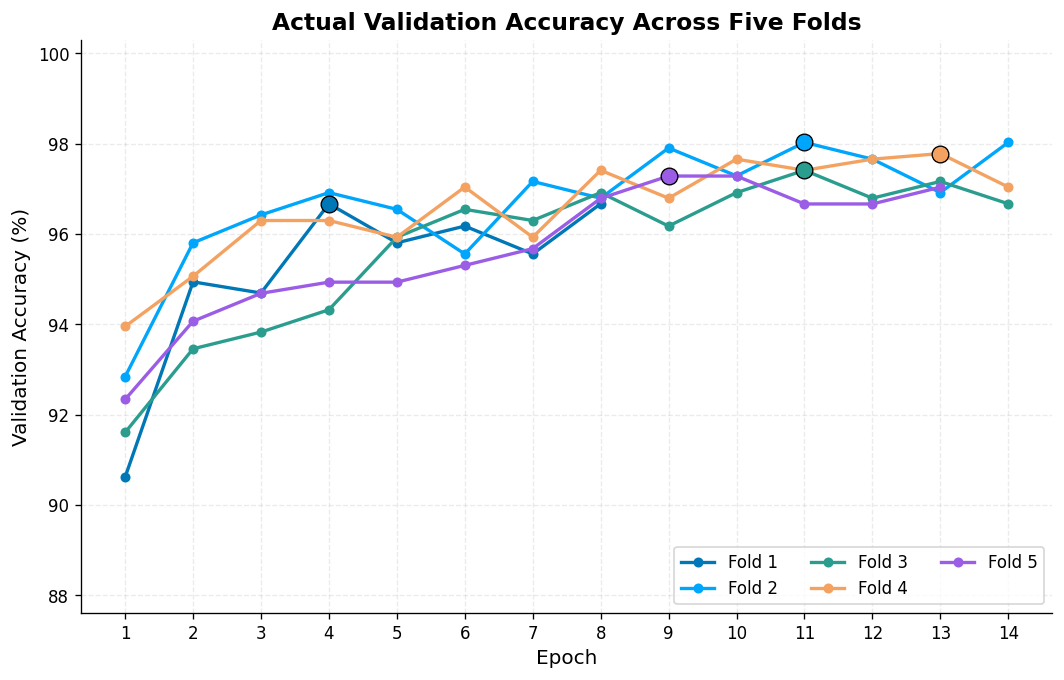

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/01_actual_validation_accuracy_by_fold.png


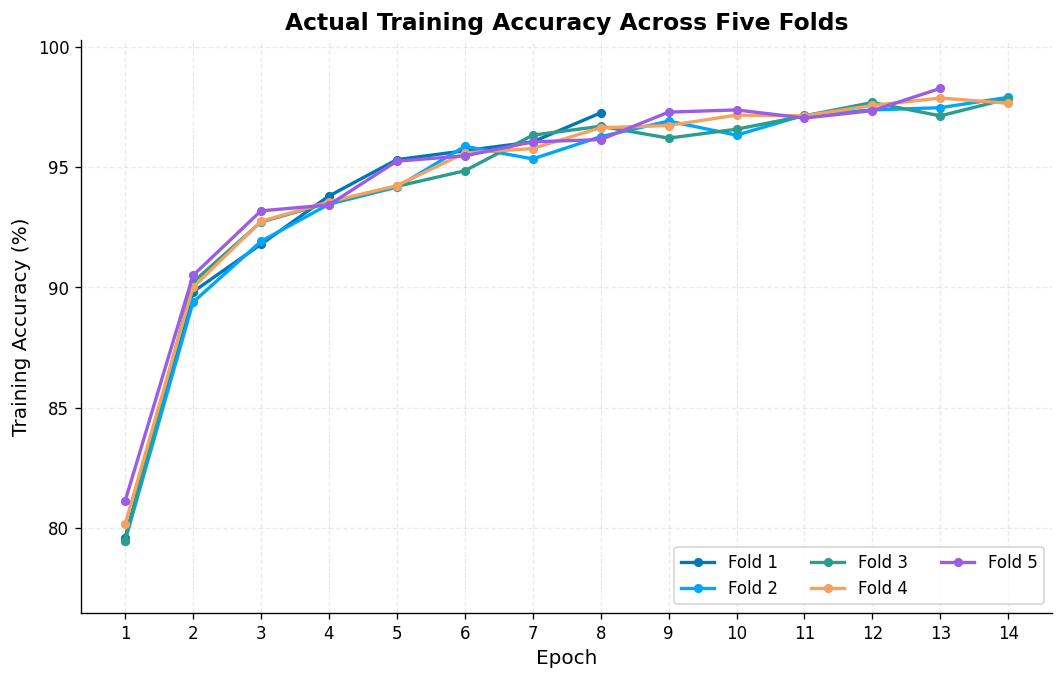

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/02_actual_training_accuracy_by_fold.png


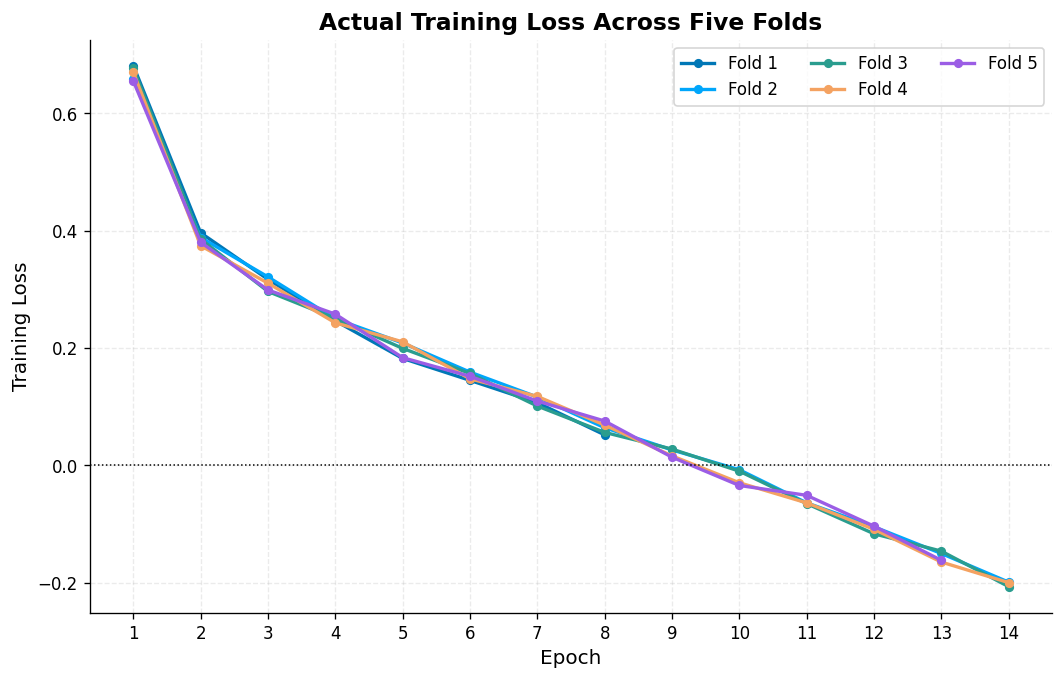

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/03_actual_training_loss_by_fold.png


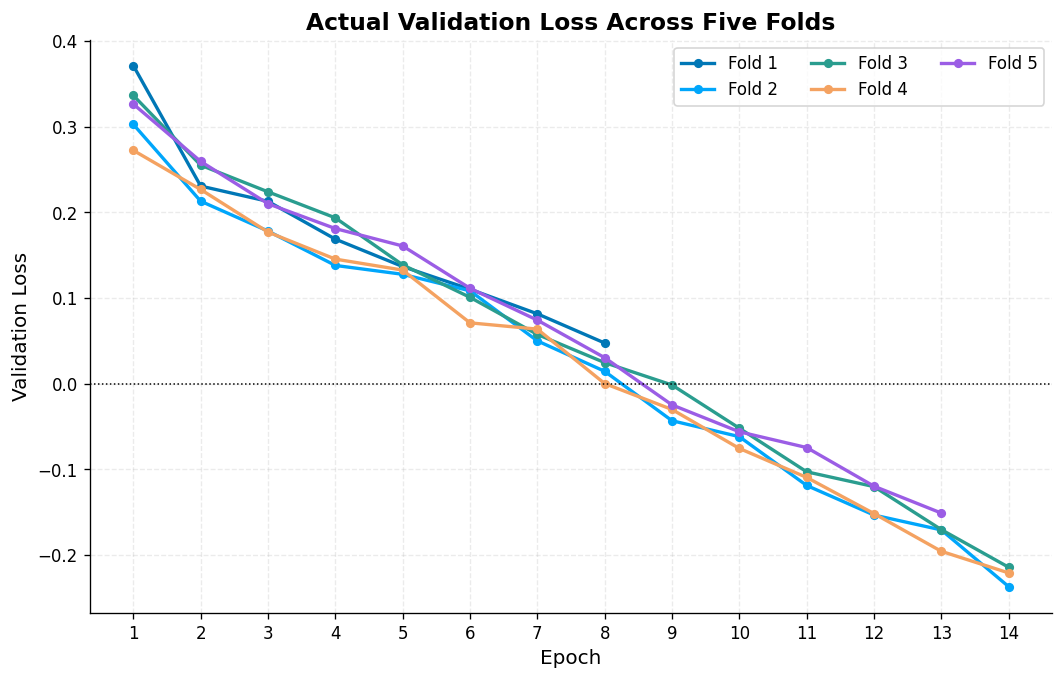

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/04_actual_validation_loss_by_fold.png


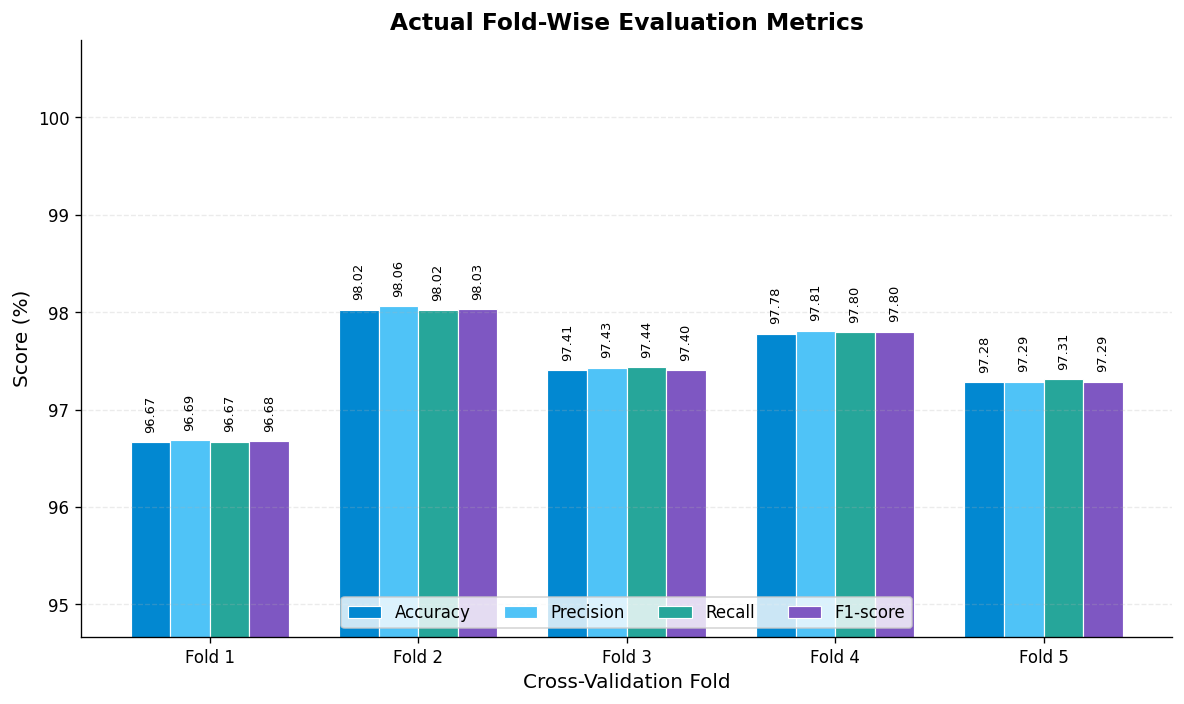

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/05_actual_foldwise_metrics.png


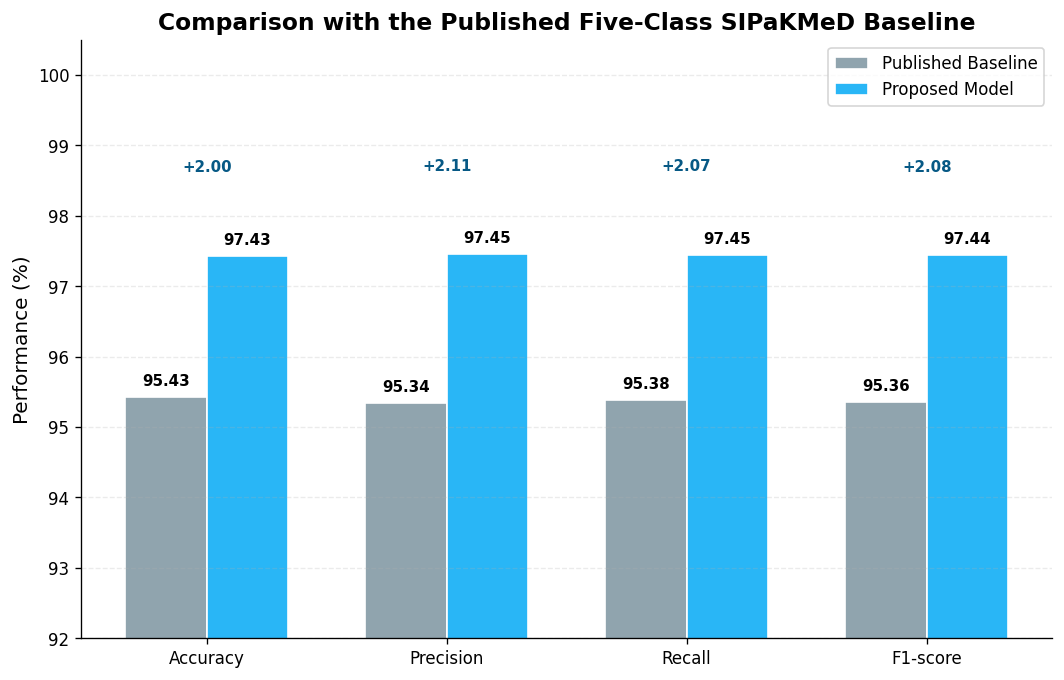

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/06_actual_baseline_vs_proposed.png


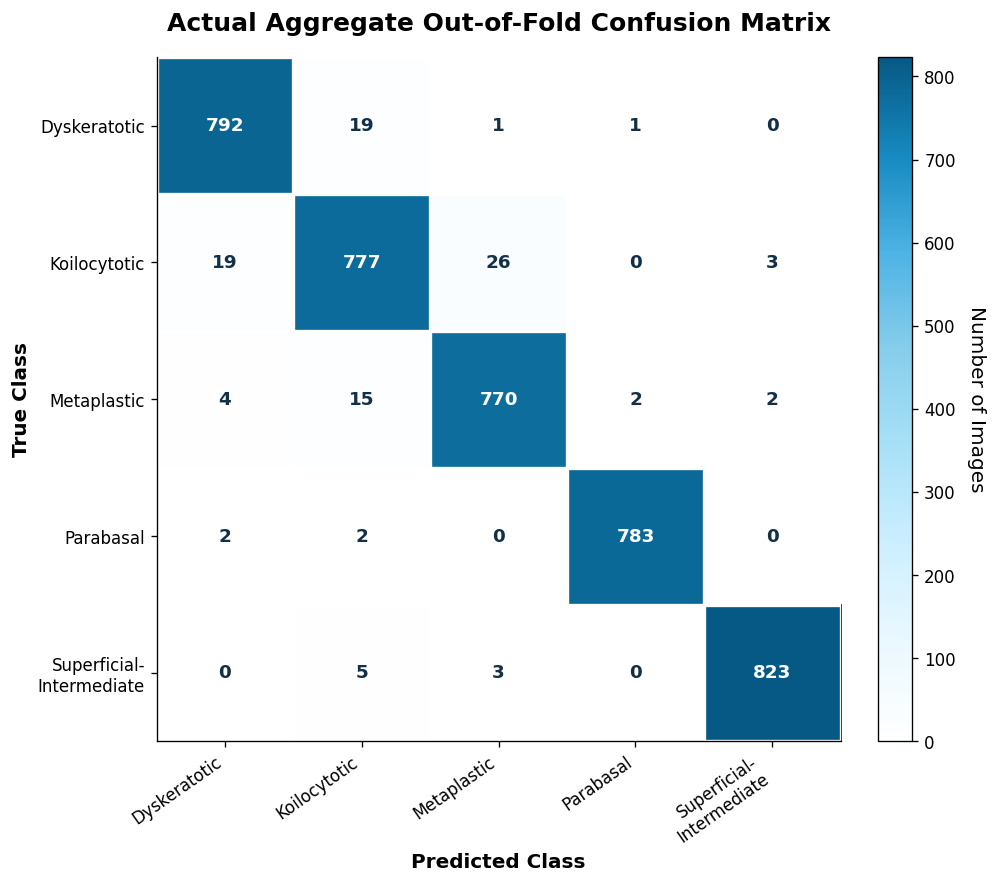

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/07_actual_confusion_matrix_counts_skyblue.png


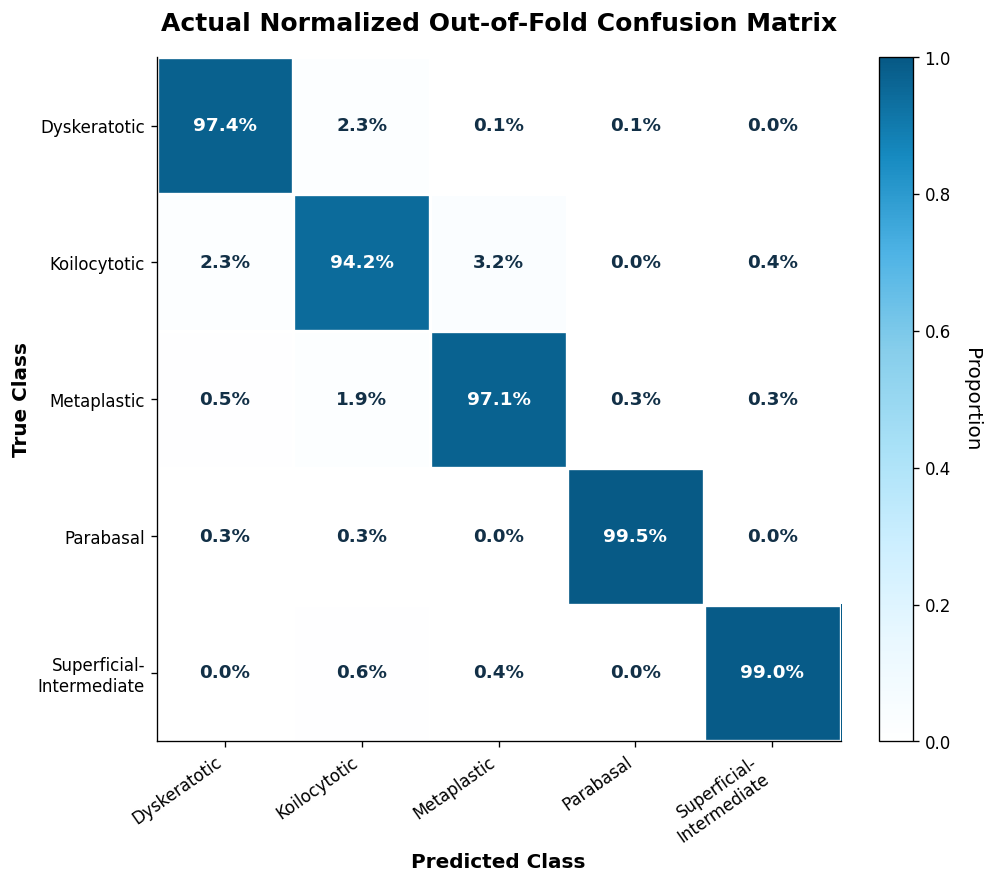

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/08_actual_confusion_matrix_normalized_skyblue.png


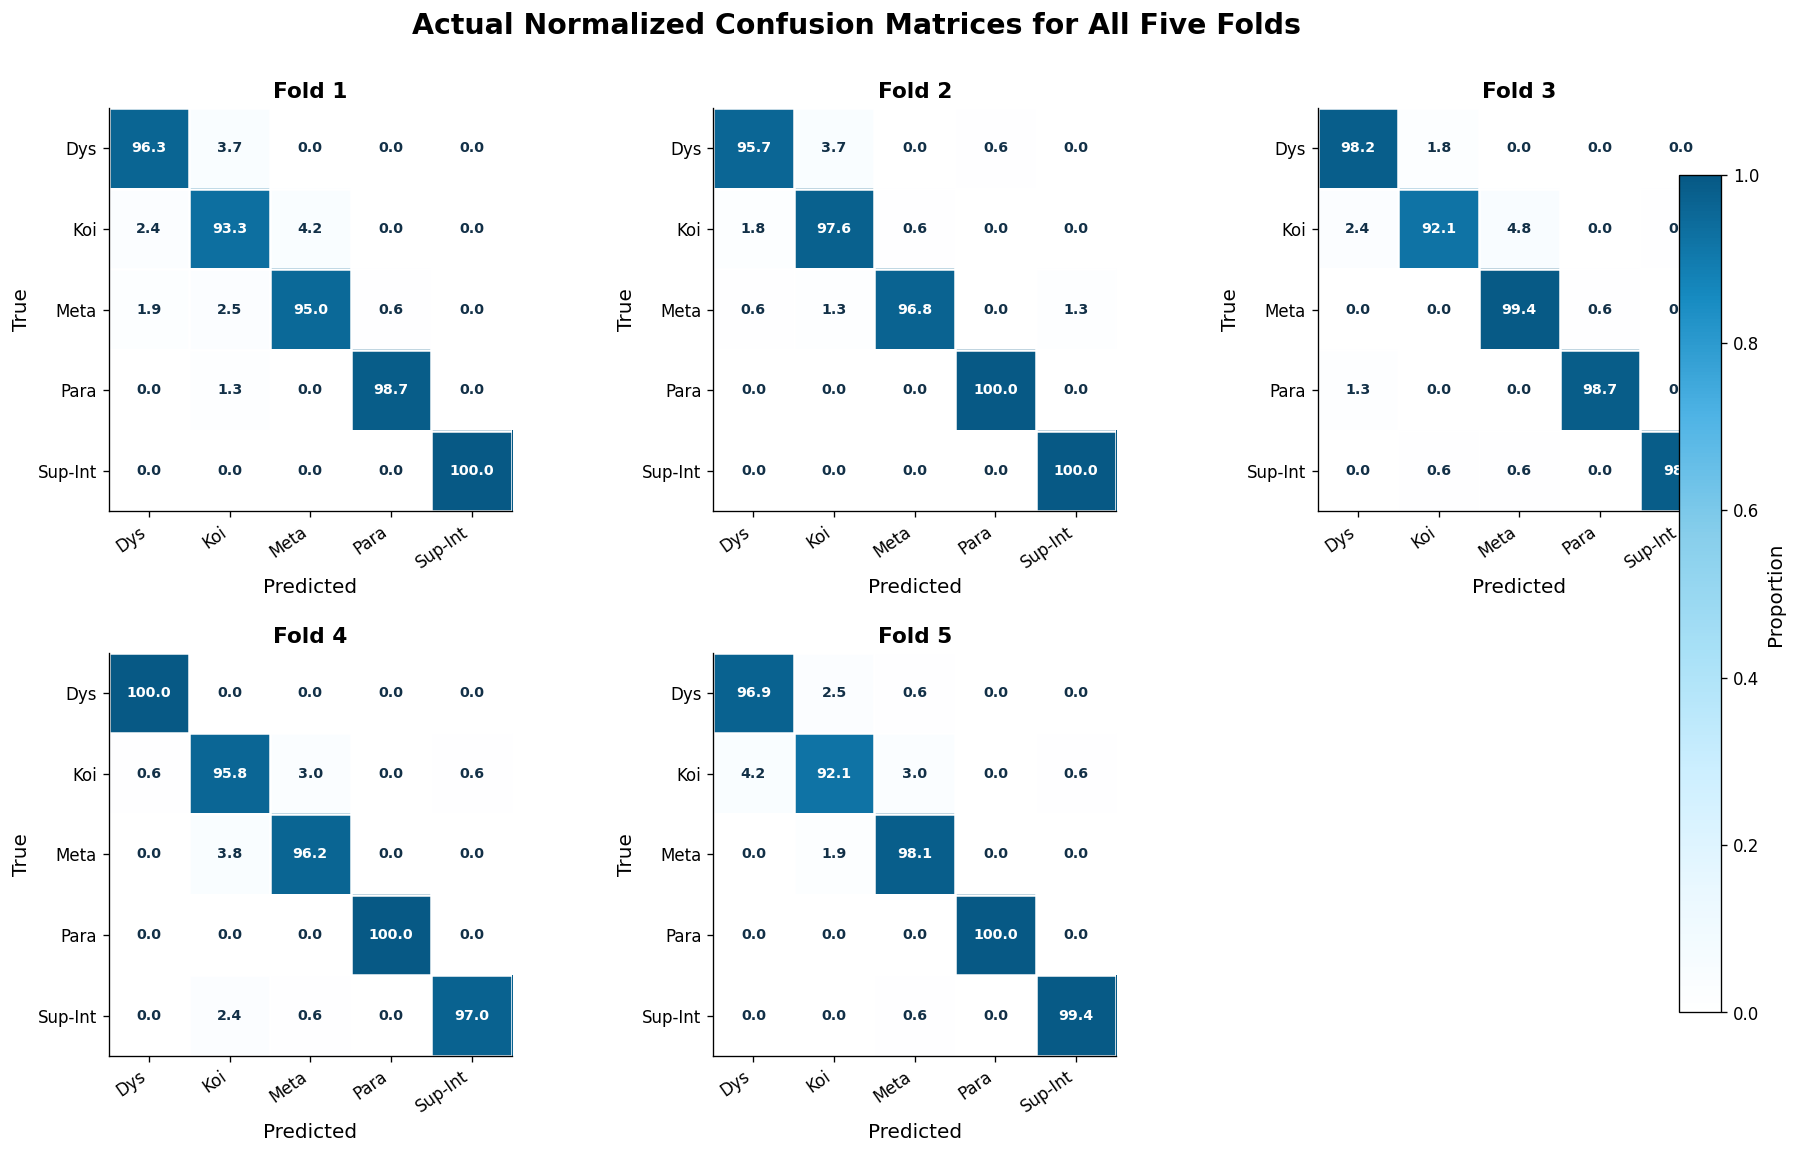

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/09_actual_per_fold_confusion_matrices_skyblue.png


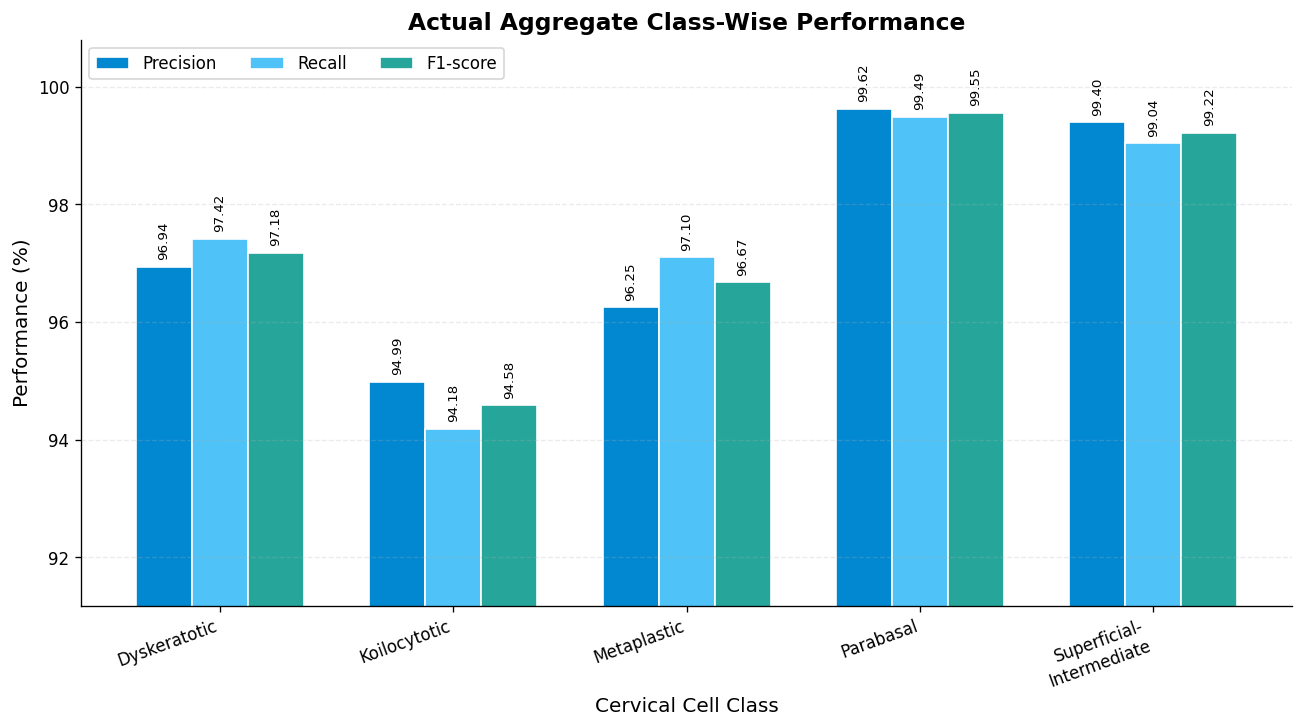

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/10_actual_classwise_metrics.png


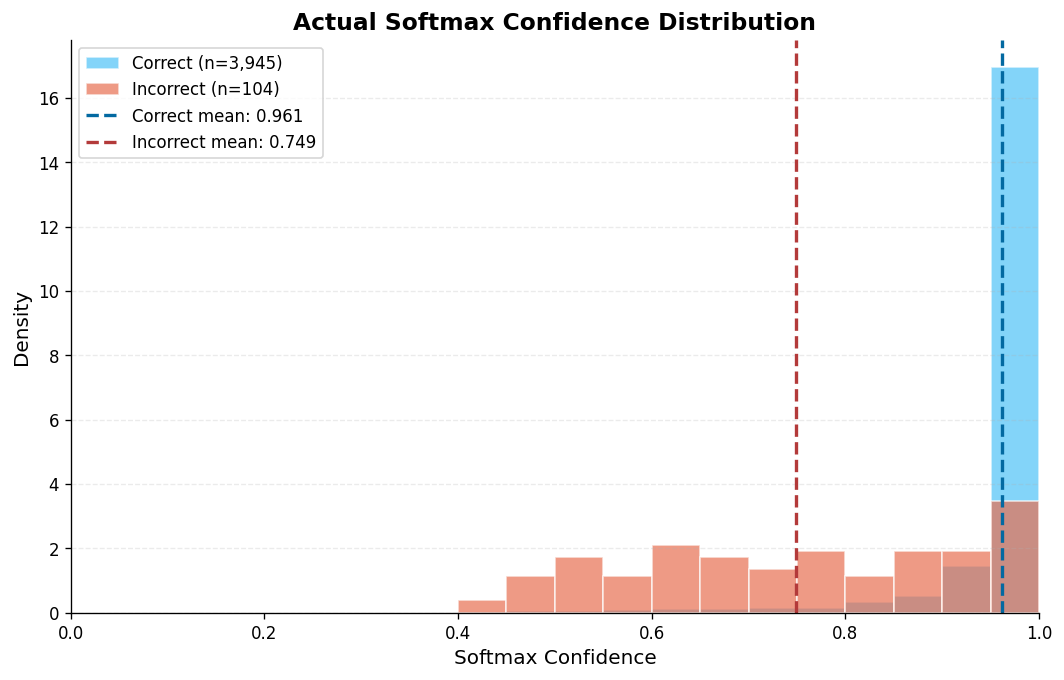

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/11_actual_softmax_confidence_distribution.png


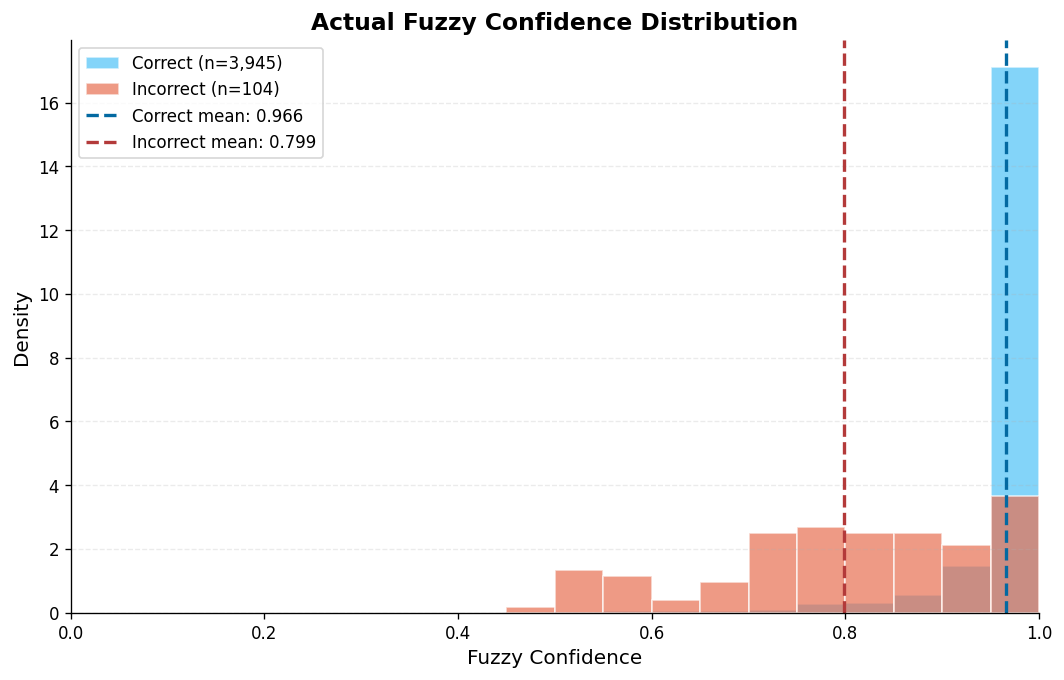

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/12_actual_fuzzy_confidence_distribution.png


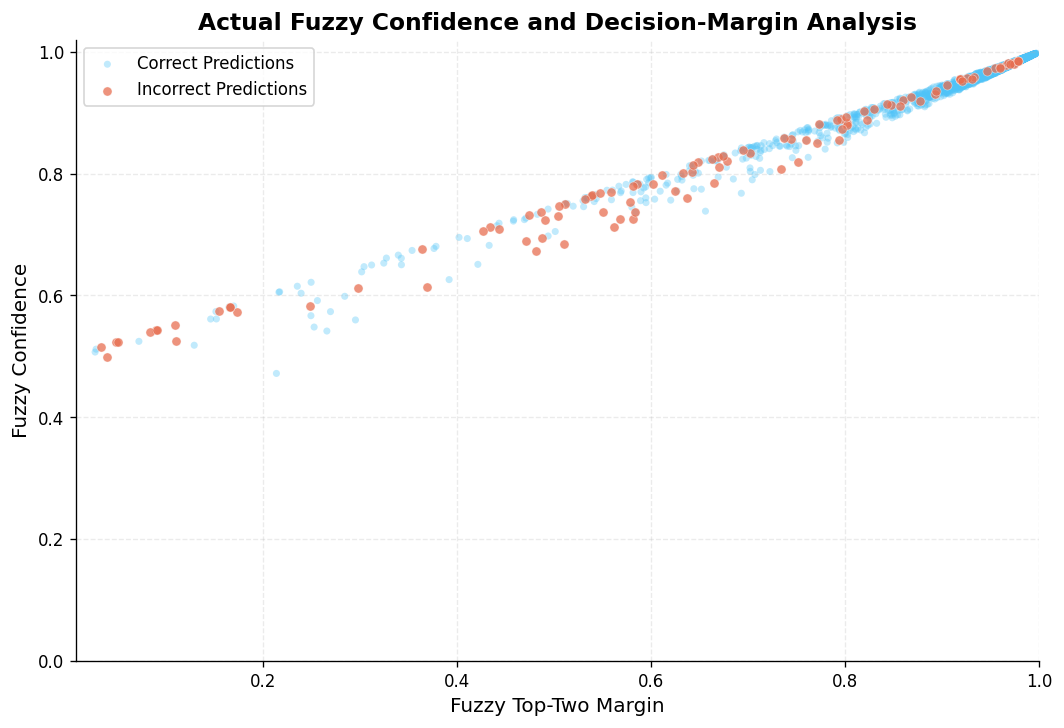

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/13_actual_confidence_margin_scatter.png


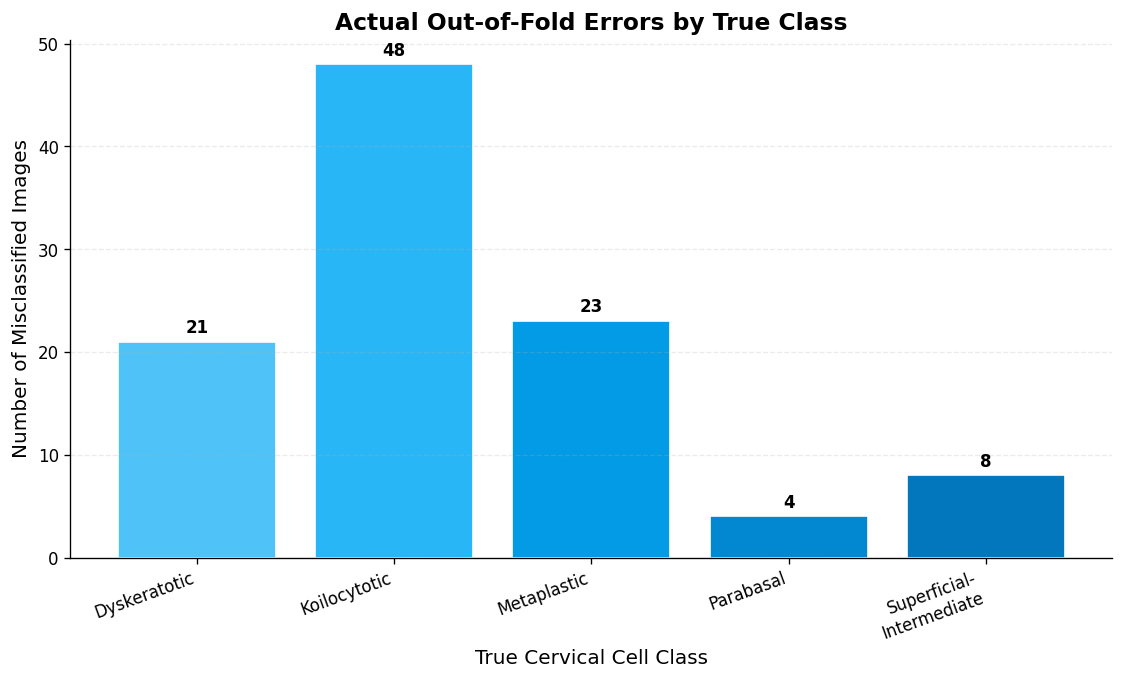

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/14_actual_errors_by_true_class.png


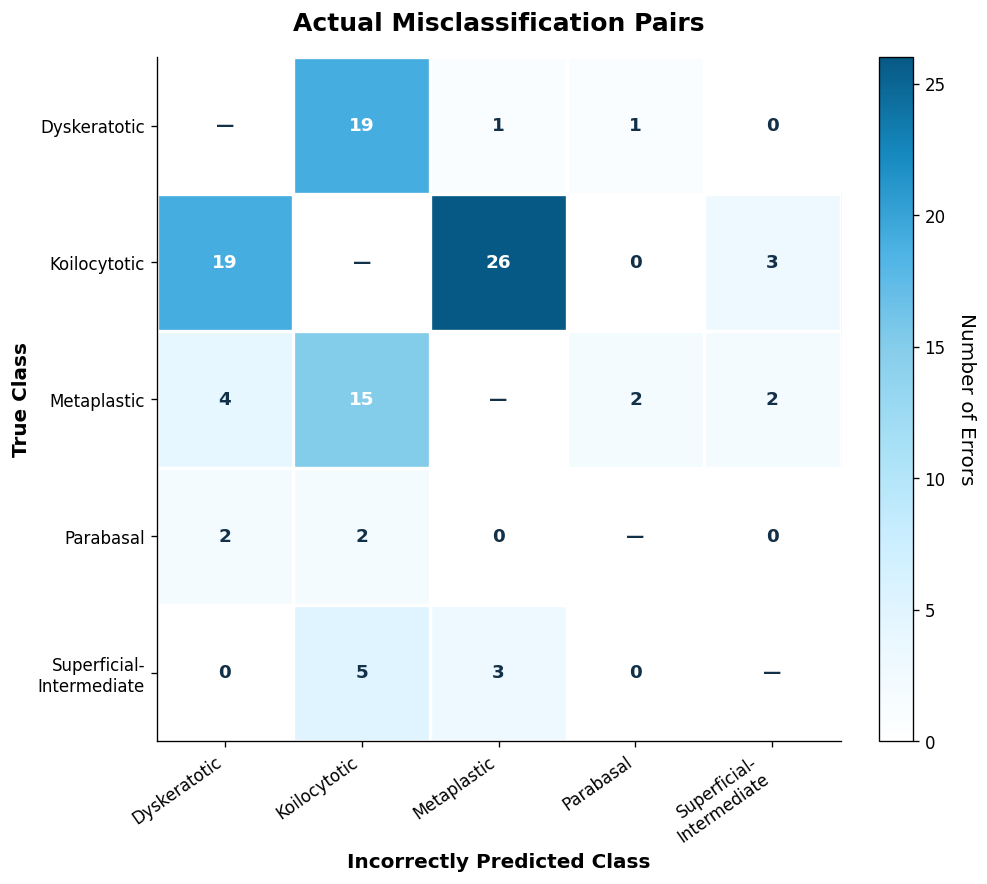

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/15_actual_misclassification_pairs_skyblue.png


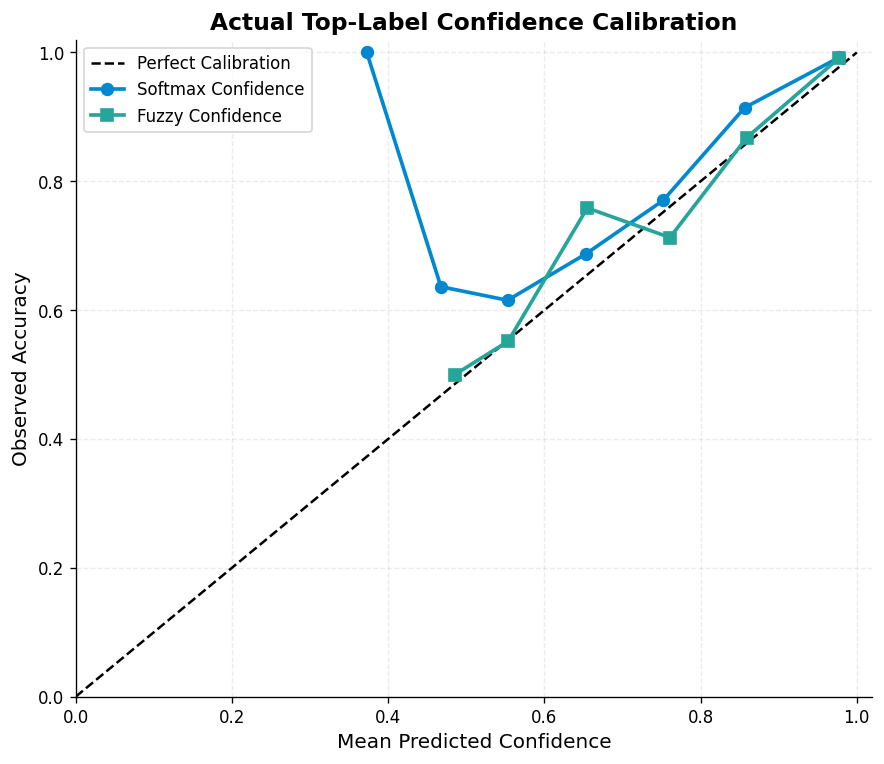

Saved: /kaggle/working/ablation_no_global_node_results/actual_report_plots/16_actual_confidence_calibration.png

ACTUAL PLOT-GENERATION SUMMARY
Total out-of-fold images       : 4,049
Correct predictions            : 3,945
Misclassifications             : 104
Aggregate OOF accuracy         : 97.43%
Mean fold accuracy            : 97.43%
Mean fold macro precision     : 97.45%
Mean fold macro recall        : 97.45%
Mean fold macro F1-score      : 97.44%
Softmax errors with conf >=.90: 28
Fuzzy errors with conf >=.90  : 30

All actual plots were saved in:
/kaggle/working/ablation_no_global_node_results/actual_report_plots

ZIP file created:
/kaggle/working/ablation_no_global_node_results/actual_report_plots.zip

Generated plot files:
 - 01_actual_validation_accuracy_by_fold.png
 - 02_actual_training_accuracy_by_fold.png
 - 03_actual_training_loss_by_fold.png
 - 04_actual_validation_loss_by_fold.png
 - 05_actual_foldwise_metrics.png
 - 06_actual_baseline_vs_proposed.png
 - 07_actual_confusi

In [17]:
# =====================================================================
# ONE KAGGLE CELL: GENERATE ALL ACTUAL REPORT PLOTS
# Run after training, evaluation, and qualitative-result cells.
#
# This cell uses:
#   training_history.csv
#   fold_metrics.csv
#   summary_metrics.csv
#   actual_out_of_fold_predictions.csv
#
# It does not generate or invent any metric values.
# =====================================================================

import os
import math
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")


# =====================================================================
# 1. LOCATE ACTUAL RESULT FILES AUTOMATICALLY
# =====================================================================

candidate_roots = []

if "OUTPUT_DIR" in globals():
    candidate_roots.append(Path(OUTPUT_DIR))

candidate_roots.extend([
    Path("/kaggle/working/enhanced_cnn_gat_fuzzy_results"),
    Path("/kaggle/working")
])

# Remove duplicate paths
unique_roots = []
for root in candidate_roots:
    if root not in unique_roots and root.exists():
        unique_roots.append(root)

candidate_roots = unique_roots


def find_result_file(filename):
    """
    Find an exact result filename in the known output directories.
    """
    # First check direct paths
    for root in candidate_roots:
        direct_path = root / filename

        if direct_path.exists():
            return direct_path

    # Then search recursively
    for root in candidate_roots:
        matches = list(root.rglob(filename))

        if matches:
            # Prefer files outside the new plot directory
            matches = [
                path for path in matches
                if "actual_report_plots" not in str(path)
            ]

            if matches:
                return matches[0]

    raise FileNotFoundError(
        f"\nCould not find: {filename}\n"
        "Make sure the training and qualitative-result cells "
        "were executed successfully."
    )


training_history_path = find_result_file("training_history.csv")
fold_metrics_path = find_result_file("fold_metrics.csv")
summary_metrics_path = find_result_file("summary_metrics.csv")
oof_predictions_path = find_result_file(
    "actual_out_of_fold_predictions.csv"
)

print("Files used for actual plots:")
print("Training history :", training_history_path)
print("Fold metrics     :", fold_metrics_path)
print("Summary metrics  :", summary_metrics_path)
print("OOF predictions  :", oof_predictions_path)


# =====================================================================
# 2. READ AND VALIDATE ACTUAL DATA
# =====================================================================

history_df = pd.read_csv(training_history_path)
fold_df = pd.read_csv(fold_metrics_path)
summary_df = pd.read_csv(summary_metrics_path)
oof_df = pd.read_csv(oof_predictions_path)

required_history_columns = {
    "fold",
    "epoch",
    "train_loss",
    "train_acc",
    "val_loss",
    "val_acc",
    "val_precision_macro",
    "val_recall_macro",
    "val_f1_macro"
}

required_fold_columns = {
    "fold",
    "best_epoch",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "n_train",
    "n_val"
}

required_oof_columns = {
    "fold",
    "true_index",
    "true_class",
    "predicted_index",
    "predicted_class",
    "correct",
    "softmax_confidence",
    "fuzzy_confidence",
    "fuzzy_margin"
}


def validate_columns(dataframe, required_columns, dataframe_name):
    missing_columns = required_columns - set(dataframe.columns)

    if missing_columns:
        raise ValueError(
            f"{dataframe_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )


validate_columns(
    history_df,
    required_history_columns,
    "training_history.csv"
)

validate_columns(
    fold_df,
    required_fold_columns,
    "fold_metrics.csv"
)

validate_columns(
    oof_df,
    required_oof_columns,
    "actual_out_of_fold_predictions.csv"
)


# Convert correct column safely to Boolean
if oof_df["correct"].dtype == bool:
    oof_df["correct_bool"] = oof_df["correct"]
else:
    oof_df["correct_bool"] = (
        oof_df["correct"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("true")
    )


# =====================================================================
# 3. OUTPUT DIRECTORY AND PROFESSIONAL PLOT SETTINGS
# =====================================================================

base_output_dir = fold_metrics_path.parent

PLOTS_DIR = base_output_dir / "actual_report_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "Dyskeratotic",
    "Koilocytotic",
    "Metaplastic",
    "Parabasal",
    "Superficial-Intermediate"
]

SHORT_CLASS_NAMES = [
    "Dyskeratotic",
    "Koilocytotic",
    "Metaplastic",
    "Parabasal",
    "Superficial-\nIntermediate"
]

CLASS_INDICES = list(range(len(CLASS_NAMES)))

# Actual baseline values reported by the assigned paper
BASELINE_METRICS = {
    "Accuracy": 95.43,
    "Precision": 95.34,
    "Recall": 95.38,
    "F1-score": 95.36
}

# Sky-blue colour scheme requested for confusion matrices
SKY_BLUE_CMAP = LinearSegmentedColormap.from_list(
    "ProfessionalSkyBlue",
    [
        "#FFFFFF",
        "#EAF8FF",
        "#CDEFFF",
        "#A9E1F7",
        "#87CEEB",
        "#4EB3E5",
        "#168AC0",
        "#075985"
    ]
)

# Colours for other report plots
FOLD_COLORS = [
    "#0077B6",
    "#00A6FB",
    "#2A9D8F",
    "#F4A261",
    "#9B5DE5"
]

METRIC_COLORS = [
    "#0288D1",
    "#4FC3F7",
    "#26A69A",
    "#7E57C2"
]

CORRECT_COLOR = "#4FC3F7"
ERROR_COLOR = "#E76F51"
BASELINE_COLOR = "#90A4AE"
PROPOSED_COLOR = "#29B6F6"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})


def percentage_values(series):
    """
    Convert fractional metric values to percentages only when required.
    """
    values = pd.to_numeric(series, errors="coerce").astype(float)

    if values.dropna().max() <= 1.5:
        values = values * 100.0

    return values


def save_and_show(fig, filename):
    """
    Save every figure as a high-resolution PNG and display it.
    """
    save_path = PLOTS_DIR / filename

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close(fig)

    print("Saved:", save_path)


# Convert actual metric columns to percentage scale
history_df["train_acc_percent"] = percentage_values(
    history_df["train_acc"]
)

history_df["val_acc_percent"] = percentage_values(
    history_df["val_acc"]
)

history_df["val_precision_percent"] = percentage_values(
    history_df["val_precision_macro"]
)

history_df["val_recall_percent"] = percentage_values(
    history_df["val_recall_macro"]
)

history_df["val_f1_percent"] = percentage_values(
    history_df["val_f1_macro"]
)

for column in [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro"
]:
    fold_df[f"{column}_percent"] = percentage_values(
        fold_df[column]
    )


# =====================================================================
# PLOT 1: ACTUAL VALIDATION ACCURACY FOR ALL FIVE FOLDS
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 5.8))

for fold_number, color in zip(
    sorted(history_df["fold"].unique()),
    FOLD_COLORS
):
    fold_history = (
        history_df[history_df["fold"] == fold_number]
        .sort_values("epoch")
    )

    ax.plot(
        fold_history["epoch"],
        fold_history["val_acc_percent"],
        marker="o",
        markersize=5,
        linewidth=2,
        color=color,
        label=f"Fold {fold_number}"
    )

    best_row = fold_df[
        fold_df["fold"] == fold_number
    ].iloc[0]

    best_epoch = int(best_row["best_epoch"])

    matching_epoch = fold_history[
        fold_history["epoch"] == best_epoch
    ]

    if not matching_epoch.empty:
        best_accuracy = matching_epoch[
            "val_acc_percent"
        ].iloc[0]

        ax.scatter(
            best_epoch,
            best_accuracy,
            s=100,
            color=color,
            edgecolor="black",
            linewidth=0.8,
            zorder=5
        )

ax.set_title(
    "Actual Validation Accuracy Across Five Folds",
    fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_xticks(
    range(
        1,
        int(history_df["epoch"].max()) + 1
    )
)
ax.set_ylim(
    max(0, history_df["val_acc_percent"].min() - 3),
    100.3
)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(
    ncol=3,
    frameon=True,
    loc="lower right"
)

fig.tight_layout()

save_and_show(
    fig,
    "01_actual_validation_accuracy_by_fold.png"
)


# =====================================================================
# PLOT 2: ACTUAL TRAINING ACCURACY FOR ALL FIVE FOLDS
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 5.8))

for fold_number, color in zip(
    sorted(history_df["fold"].unique()),
    FOLD_COLORS
):
    fold_history = (
        history_df[history_df["fold"] == fold_number]
        .sort_values("epoch")
    )

    ax.plot(
        fold_history["epoch"],
        fold_history["train_acc_percent"],
        marker="o",
        markersize=4.5,
        linewidth=2,
        color=color,
        label=f"Fold {fold_number}"
    )

ax.set_title(
    "Actual Training Accuracy Across Five Folds",
    fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Accuracy (%)")
ax.set_xticks(
    range(
        1,
        int(history_df["epoch"].max()) + 1
    )
)
ax.set_ylim(
    max(0, history_df["train_acc_percent"].min() - 3),
    100.3
)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(
    ncol=3,
    frameon=True,
    loc="lower right"
)

fig.tight_layout()

save_and_show(
    fig,
    "02_actual_training_accuracy_by_fold.png"
)


# =====================================================================
# PLOT 3: ACTUAL TRAINING LOSS FOR ALL FIVE FOLDS
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 5.8))

for fold_number, color in zip(
    sorted(history_df["fold"].unique()),
    FOLD_COLORS
):
    fold_history = (
        history_df[history_df["fold"] == fold_number]
        .sort_values("epoch")
    )

    ax.plot(
        fold_history["epoch"],
        fold_history["train_loss"],
        marker="o",
        markersize=4.5,
        linewidth=2,
        color=color,
        label=f"Fold {fold_number}"
    )

ax.axhline(
    0,
    color="black",
    linewidth=0.9,
    linestyle=":"
)

ax.set_title(
    "Actual Training Loss Across Five Folds",
    fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_xticks(
    range(
        1,
        int(history_df["epoch"].max()) + 1
    )
)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(
    ncol=3,
    frameon=True
)

fig.tight_layout()

save_and_show(
    fig,
    "03_actual_training_loss_by_fold.png"
)


# =====================================================================
# PLOT 4: ACTUAL VALIDATION LOSS FOR ALL FIVE FOLDS
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 5.8))

for fold_number, color in zip(
    sorted(history_df["fold"].unique()),
    FOLD_COLORS
):
    fold_history = (
        history_df[history_df["fold"] == fold_number]
        .sort_values("epoch")
    )

    ax.plot(
        fold_history["epoch"],
        fold_history["val_loss"],
        marker="o",
        markersize=4.5,
        linewidth=2,
        color=color,
        label=f"Fold {fold_number}"
    )

ax.axhline(
    0,
    color="black",
    linewidth=0.9,
    linestyle=":"
)

ax.set_title(
    "Actual Validation Loss Across Five Folds",
    fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_xticks(
    range(
        1,
        int(history_df["epoch"].max()) + 1
    )
)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(
    ncol=3,
    frameon=True
)

fig.tight_layout()

save_and_show(
    fig,
    "04_actual_validation_loss_by_fold.png"
)


# =====================================================================
# PLOT 5: ACTUAL FOLD-WISE ACCURACY, PRECISION, RECALL AND F1
# =====================================================================

metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

metric_columns = [
    "accuracy_percent",
    "precision_macro_percent",
    "recall_macro_percent",
    "f1_macro_percent"
]

fold_numbers = fold_df["fold"].astype(int).to_numpy()
x_positions = np.arange(len(fold_numbers))
bar_width = 0.19

fig, ax = plt.subplots(figsize=(10, 6))

for metric_position, (
    metric_label,
    metric_column,
    metric_color
) in enumerate(
    zip(
        metric_labels,
        metric_columns,
        METRIC_COLORS
    )
):
    offset = (
        metric_position -
        (len(metric_labels) - 1) / 2
    ) * bar_width

    bars = ax.bar(
        x_positions + offset,
        fold_df[metric_column],
        width=bar_width,
        color=metric_color,
        edgecolor="white",
        linewidth=0.7,
        label=metric_label
    )

    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.10,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.8,
            rotation=90
        )

ax.set_title(
    "Actual Fold-Wise Evaluation Metrics",
    fontweight="bold"
)
ax.set_xlabel("Cross-Validation Fold")
ax.set_ylabel("Score (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [f"Fold {fold}" for fold in fold_numbers]
)
ax.set_ylim(
    max(
        0,
        fold_df[metric_columns].min().min() - 2
    ),
    100.8
)
ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)
ax.legend(
    ncol=4,
    loc="lower center",
    frameon=True
)

fig.tight_layout()

save_and_show(
    fig,
    "05_actual_foldwise_metrics.png"
)


# =====================================================================
# PLOT 6: ACTUAL PROPOSED MODEL VS PUBLISHED BASELINE
# =====================================================================

proposed_metrics = [
    fold_df["accuracy_percent"].mean(),
    fold_df["precision_macro_percent"].mean(),
    fold_df["recall_macro_percent"].mean(),
    fold_df["f1_macro_percent"].mean()
]

baseline_metrics = [
    BASELINE_METRICS["Accuracy"],
    BASELINE_METRICS["Precision"],
    BASELINE_METRICS["Recall"],
    BASELINE_METRICS["F1-score"]
]

metric_positions = np.arange(len(metric_labels))
comparison_width = 0.34

fig, ax = plt.subplots(figsize=(9, 5.8))

baseline_bars = ax.bar(
    metric_positions - comparison_width / 2,
    baseline_metrics,
    width=comparison_width,
    color=BASELINE_COLOR,
    edgecolor="white",
    label="Published Baseline"
)

proposed_bars = ax.bar(
    metric_positions + comparison_width / 2,
    proposed_metrics,
    width=comparison_width,
    color=PROPOSED_COLOR,
    edgecolor="white",
    label="Proposed Model"
)

for bars in [baseline_bars, proposed_bars]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.12,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

for metric_position, (
    baseline_value,
    proposed_value
) in enumerate(
    zip(
        baseline_metrics,
        proposed_metrics
    )
):
    gain = proposed_value - baseline_value

    ax.text(
        metric_position,
        max(baseline_value, proposed_value) + 1.15,
        f"+{gain:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#075985",
        fontweight="bold"
    )

ax.set_title(
    "Comparison with the Published Five-Class SIPaKMeD Baseline",
    fontweight="bold"
)
ax.set_ylabel("Performance (%)")
ax.set_xticks(metric_positions)
ax.set_xticklabels(metric_labels)
ax.set_ylim(92, 100.5)
ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)
ax.legend(frameon=True)

fig.tight_layout()

save_and_show(
    fig,
    "06_actual_baseline_vs_proposed.png"
)


# =====================================================================
# 4. COMPUTE ACTUAL AGGREGATE OUT-OF-FOLD RESULTS
# =====================================================================

true_labels = (
    pd.to_numeric(
        oof_df["true_index"],
        errors="raise"
    )
    .astype(int)
    .to_numpy()
)

predicted_labels = (
    pd.to_numeric(
        oof_df["predicted_index"],
        errors="raise"
    )
    .astype(int)
    .to_numpy()
)

aggregate_cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=CLASS_INDICES
)

aggregate_cm_normalized = (
    aggregate_cm /
    aggregate_cm.sum(
        axis=1,
        keepdims=True
    ).clip(min=1)
)


# =====================================================================
# CONFUSION-MATRIX PLOTTING FUNCTION: SKY-BLUE THEME
# =====================================================================

def draw_confusion_matrix(
    matrix,
    title,
    filename,
    normalized=False
):
    fig, ax = plt.subplots(
        figsize=(9.2, 7.5)
    )

    if normalized:
        image = ax.imshow(
            matrix,
            cmap=SKY_BLUE_CMAP,
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )
    else:
        image = ax.imshow(
            matrix,
            cmap=SKY_BLUE_CMAP,
            vmin=0,
            interpolation="nearest"
        )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=16
    )
    ax.set_xlabel(
        "Predicted Class",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_ylabel(
        "True Class",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xticks(
        np.arange(len(SHORT_CLASS_NAMES))
    )
    ax.set_yticks(
        np.arange(len(SHORT_CLASS_NAMES))
    )

    ax.set_xticklabels(
        SHORT_CLASS_NAMES,
        rotation=35,
        ha="right"
    )
    ax.set_yticklabels(
        SHORT_CLASS_NAMES
    )

    maximum_value = matrix.max()

    for row_index in range(
        matrix.shape[0]
    ):
        for column_index in range(
            matrix.shape[1]
        ):
            value = matrix[
                row_index,
                column_index
            ]

            if normalized:
                display_text = f"{value * 100:.1f}%"
                threshold = 0.48
            else:
                display_text = f"{int(value)}"
                threshold = maximum_value * 0.50

            text_color = (
                "white"
                if value > threshold
                else "#123047"
            )

            ax.text(
                column_index,
                row_index,
                display_text,
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color
            )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    if normalized:
        colorbar.set_label(
            "Proportion",
            rotation=270,
            labelpad=18
        )
    else:
        colorbar.set_label(
            "Number of Images",
            rotation=270,
            labelpad=18
        )

    ax.set_xticks(
        np.arange(-0.5, len(CLASS_NAMES), 1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-0.5, len(CLASS_NAMES), 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linewidth=2
    )
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    fig.tight_layout()

    save_and_show(
        fig,
        filename
    )


# =====================================================================
# PLOT 7: SKY-BLUE AGGREGATE CONFUSION MATRIX — COUNTS
# =====================================================================

draw_confusion_matrix(
    aggregate_cm,
    "Actual Aggregate Out-of-Fold Confusion Matrix",
    "07_actual_confusion_matrix_counts_skyblue.png",
    normalized=False
)


# =====================================================================
# PLOT 8: SKY-BLUE AGGREGATE CONFUSION MATRIX — NORMALIZED
# =====================================================================

draw_confusion_matrix(
    aggregate_cm_normalized,
    "Actual Normalized Out-of-Fold Confusion Matrix",
    "08_actual_confusion_matrix_normalized_skyblue.png",
    normalized=True
)


# =====================================================================
# PLOT 9: NORMALIZED SKY-BLUE CONFUSION MATRIX FOR EACH FOLD
# =====================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.ravel()

last_image = None

for plot_index, fold_number in enumerate(
    sorted(oof_df["fold"].unique())
):
    current_fold = oof_df[
        oof_df["fold"] == fold_number
    ]

    fold_true = (
        current_fold["true_index"]
        .astype(int)
        .to_numpy()
    )

    fold_predicted = (
        current_fold["predicted_index"]
        .astype(int)
        .to_numpy()
    )

    fold_cm = confusion_matrix(
        fold_true,
        fold_predicted,
        labels=CLASS_INDICES
    )

    fold_cm_normalized = (
        fold_cm /
        fold_cm.sum(
            axis=1,
            keepdims=True
        ).clip(min=1)
    )

    axis = axes[plot_index]

    last_image = axis.imshow(
        fold_cm_normalized,
        cmap=SKY_BLUE_CMAP,
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    axis.set_title(
        f"Fold {int(fold_number)}",
        fontsize=13,
        fontweight="bold"
    )

    axis.set_xticks(
        np.arange(len(CLASS_NAMES))
    )
    axis.set_yticks(
        np.arange(len(CLASS_NAMES))
    )

    axis.set_xticklabels(
        ["Dys", "Koi", "Meta", "Para", "Sup-Int"],
        rotation=35,
        ha="right"
    )

    axis.set_yticklabels(
        ["Dys", "Koi", "Meta", "Para", "Sup-Int"]
    )

    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")

    for row_index in range(5):
        for column_index in range(5):
            value = fold_cm_normalized[
                row_index,
                column_index
            ]

            axis.text(
                column_index,
                row_index,
                f"{value * 100:.1f}",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color=(
                    "white"
                    if value > 0.48
                    else "#123047"
                )
            )

    axis.set_xticks(
        np.arange(-0.5, 5, 1),
        minor=True
    )
    axis.set_yticks(
        np.arange(-0.5, 5, 1),
        minor=True
    )

    axis.grid(
        which="minor",
        color="white",
        linewidth=1.5
    )
    axis.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

# Remove unused sixth subplot
axes[-1].axis("off")

fig.suptitle(
    "Actual Normalized Confusion Matrices for All Five Folds",
    fontsize=17,
    fontweight="bold"
)

fig.colorbar(
    last_image,
    ax=axes.tolist(),
    fraction=0.025,
    pad=0.02,
    label="Proportion"
)

fig.subplots_adjust(
    top=0.90,
    wspace=0.30,
    hspace=0.35
)

save_and_show(
    fig,
    "09_actual_per_fold_confusion_matrices_skyblue.png"
)


# =====================================================================
# 5. ACTUAL CLASS-WISE PRECISION, RECALL AND F1
# =====================================================================

class_precision, class_recall, class_f1, class_support = (
    precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=CLASS_INDICES,
        zero_division=0
    )
)

class_metric_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": class_precision * 100,
    "Recall": class_recall * 100,
    "F1-score": class_f1 * 100,
    "Support": class_support
})

class_metric_df.to_csv(
    PLOTS_DIR / "actual_classwise_metrics.csv",
    index=False
)


# =====================================================================
# PLOT 10: ACTUAL CLASS-WISE METRICS
# =====================================================================

x_positions = np.arange(len(CLASS_NAMES))
class_bar_width = 0.24

fig, ax = plt.subplots(
    figsize=(11, 6.2)
)

for metric_index, (
    metric_name,
    metric_color
) in enumerate([
    ("Precision", "#0288D1"),
    ("Recall", "#4FC3F7"),
    ("F1-score", "#26A69A")
]):
    offset = (
        metric_index - 1
    ) * class_bar_width

    bars = ax.bar(
        x_positions + offset,
        class_metric_df[metric_name],
        width=class_bar_width,
        color=metric_color,
        edgecolor="white",
        label=metric_name
    )

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.12,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_title(
    "Actual Aggregate Class-Wise Performance",
    fontweight="bold"
)
ax.set_xlabel("Cervical Cell Class")
ax.set_ylabel("Performance (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(
    SHORT_CLASS_NAMES,
    rotation=20,
    ha="right"
)
ax.set_ylim(
    max(
        0,
        class_metric_df[
            ["Precision", "Recall", "F1-score"]
        ].min().min() - 3
    ),
    100.8
)
ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)
ax.legend(
    ncol=3,
    frameon=True
)

fig.tight_layout()

save_and_show(
    fig,
    "10_actual_classwise_metrics.png"
)


# =====================================================================
# 6. ACTUAL CONFIDENCE ANALYSIS
# =====================================================================

correct_predictions = oof_df[
    oof_df["correct_bool"]
].copy()

incorrect_predictions = oof_df[
    ~oof_df["correct_bool"]
].copy()


# =====================================================================
# PLOT 11: SOFTMAX CONFIDENCE — CORRECT VS INCORRECT
# =====================================================================

fig, ax = plt.subplots(
    figsize=(9, 5.8)
)

confidence_bins = np.linspace(
    0,
    1,
    21
)

ax.hist(
    correct_predictions["softmax_confidence"],
    bins=confidence_bins,
    density=True,
    alpha=0.70,
    color=CORRECT_COLOR,
    edgecolor="white",
    label=(
        f"Correct "
        f"(n={len(correct_predictions):,})"
    )
)

ax.hist(
    incorrect_predictions["softmax_confidence"],
    bins=confidence_bins,
    density=True,
    alpha=0.70,
    color=ERROR_COLOR,
    edgecolor="white",
    label=(
        f"Incorrect "
        f"(n={len(incorrect_predictions):,})"
    )
)

ax.axvline(
    correct_predictions[
        "softmax_confidence"
    ].mean(),
    color="#0369A1",
    linestyle="--",
    linewidth=2,
    label=(
        "Correct mean: "
        f"{correct_predictions['softmax_confidence'].mean():.3f}"
    )
)

ax.axvline(
    incorrect_predictions[
        "softmax_confidence"
    ].mean(),
    color="#B33A3A",
    linestyle="--",
    linewidth=2,
    label=(
        "Incorrect mean: "
        f"{incorrect_predictions['softmax_confidence'].mean():.3f}"
    )
)

ax.set_title(
    "Actual Softmax Confidence Distribution",
    fontweight="bold"
)
ax.set_xlabel("Softmax Confidence")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)
ax.legend(frameon=True)

fig.tight_layout()

save_and_show(
    fig,
    "11_actual_softmax_confidence_distribution.png"
)


# =====================================================================
# PLOT 12: FUZZY CONFIDENCE — CORRECT VS INCORRECT
# =====================================================================

fig, ax = plt.subplots(
    figsize=(9, 5.8)
)

ax.hist(
    correct_predictions["fuzzy_confidence"],
    bins=confidence_bins,
    density=True,
    alpha=0.70,
    color=CORRECT_COLOR,
    edgecolor="white",
    label=(
        f"Correct "
        f"(n={len(correct_predictions):,})"
    )
)

ax.hist(
    incorrect_predictions["fuzzy_confidence"],
    bins=confidence_bins,
    density=True,
    alpha=0.70,
    color=ERROR_COLOR,
    edgecolor="white",
    label=(
        f"Incorrect "
        f"(n={len(incorrect_predictions):,})"
    )
)

ax.axvline(
    correct_predictions[
        "fuzzy_confidence"
    ].mean(),
    color="#0369A1",
    linestyle="--",
    linewidth=2,
    label=(
        "Correct mean: "
        f"{correct_predictions['fuzzy_confidence'].mean():.3f}"
    )
)

ax.axvline(
    incorrect_predictions[
        "fuzzy_confidence"
    ].mean(),
    color="#B33A3A",
    linestyle="--",
    linewidth=2,
    label=(
        "Incorrect mean: "
        f"{incorrect_predictions['fuzzy_confidence'].mean():.3f}"
    )
)

ax.set_title(
    "Actual Fuzzy Confidence Distribution",
    fontweight="bold"
)
ax.set_xlabel("Fuzzy Confidence")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)
ax.legend(frameon=True)

fig.tight_layout()

save_and_show(
    fig,
    "12_actual_fuzzy_confidence_distribution.png"
)


# =====================================================================
# PLOT 13: FUZZY CONFIDENCE VS FUZZY MARGIN
# =====================================================================

fig, ax = plt.subplots(
    figsize=(9, 6.2)
)

ax.scatter(
    correct_predictions["fuzzy_margin"],
    correct_predictions["fuzzy_confidence"],
    s=18,
    alpha=0.35,
    color=CORRECT_COLOR,
    edgecolors="none",
    label="Correct Predictions"
)

ax.scatter(
    incorrect_predictions["fuzzy_margin"],
    incorrect_predictions["fuzzy_confidence"],
    s=30,
    alpha=0.75,
    color=ERROR_COLOR,
    edgecolors="white",
    linewidths=0.3,
    label="Incorrect Predictions"
)

ax.set_title(
    "Actual Fuzzy Confidence and Decision-Margin Analysis",
    fontweight="bold"
)
ax.set_xlabel("Fuzzy Top-Two Margin")
ax.set_ylabel("Fuzzy Confidence")
ax.set_xlim(
    max(
        0,
        oof_df["fuzzy_margin"].min() - 0.02
    ),
    min(
        1,
        oof_df["fuzzy_margin"].max() + 0.02
    )
)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=True)

fig.tight_layout()

save_and_show(
    fig,
    "13_actual_confidence_margin_scatter.png"
)


# =====================================================================
# 7. ACTUAL ERROR ANALYSIS
# =====================================================================

errors_by_true_class = (
    incorrect_predictions
    .groupby("true_index")
    .size()
    .reindex(CLASS_INDICES, fill_value=0)
)


# =====================================================================
# PLOT 14: NUMBER OF ERRORS FROM EACH TRUE CLASS
# =====================================================================

fig, ax = plt.subplots(
    figsize=(9.5, 5.8)
)

bars = ax.bar(
    np.arange(len(CLASS_NAMES)),
    errors_by_true_class.values,
    color=[
        "#4FC3F7",
        "#29B6F6",
        "#039BE5",
        "#0288D1",
        "#0277BD"
    ],
    edgecolor="white"
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Actual Out-of-Fold Errors by True Class",
    fontweight="bold"
)
ax.set_xlabel("True Cervical Cell Class")
ax.set_ylabel("Number of Misclassified Images")
ax.set_xticks(
    np.arange(len(CLASS_NAMES))
)
ax.set_xticklabels(
    SHORT_CLASS_NAMES,
    rotation=20,
    ha="right"
)
ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--"
)

fig.tight_layout()

save_and_show(
    fig,
    "14_actual_errors_by_true_class.png"
)


# =====================================================================
# PLOT 15: SKY-BLUE MISCLASSIFICATION-PAIR HEATMAP
# =====================================================================

error_pair_matrix = aggregate_cm.copy()

# Remove correct classifications to show only errors
np.fill_diagonal(
    error_pair_matrix,
    0
)

fig, ax = plt.subplots(
    figsize=(9.2, 7.5)
)

image = ax.imshow(
    error_pair_matrix,
    cmap=SKY_BLUE_CMAP,
    vmin=0,
    interpolation="nearest"
)

ax.set_title(
    "Actual Misclassification Pairs",
    fontsize=15,
    fontweight="bold",
    pad=16
)
ax.set_xlabel(
    "Incorrectly Predicted Class",
    fontweight="bold"
)
ax.set_ylabel(
    "True Class",
    fontweight="bold"
)

ax.set_xticks(
    np.arange(len(CLASS_NAMES))
)
ax.set_yticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_xticklabels(
    SHORT_CLASS_NAMES,
    rotation=35,
    ha="right"
)
ax.set_yticklabels(
    SHORT_CLASS_NAMES
)

maximum_error = max(
    1,
    error_pair_matrix.max()
)

for row_index in range(5):
    for column_index in range(5):
        value = int(
            error_pair_matrix[
                row_index,
                column_index
            ]
        )

        display_text = (
            "—"
            if row_index == column_index
            else str(value)
        )

        ax.text(
            column_index,
            row_index,
            display_text,
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=(
                "white"
                if value > maximum_error * 0.50
                else "#123047"
            )
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

colorbar.set_label(
    "Number of Errors",
    rotation=270,
    labelpad=18
)

ax.set_xticks(
    np.arange(-0.5, 5, 1),
    minor=True
)
ax.set_yticks(
    np.arange(-0.5, 5, 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)
ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

fig.tight_layout()

save_and_show(
    fig,
    "15_actual_misclassification_pairs_skyblue.png"
)


# =====================================================================
# PLOT 16: ACTUAL TOP-LABEL CONFIDENCE CALIBRATION
# =====================================================================

def calculate_calibration(confidence_values, correctness, bins=10):
    confidence_values = np.asarray(
        confidence_values,
        dtype=float
    )

    correctness = np.asarray(
        correctness,
        dtype=float
    )

    bin_edges = np.linspace(
        0,
        1,
        bins + 1
    )

    mean_confidences = []
    observed_accuracies = []
    sample_counts = []

    for bin_index in range(bins):
        lower_bound = bin_edges[bin_index]
        upper_bound = bin_edges[bin_index + 1]

        if bin_index == bins - 1:
            selected = (
                (confidence_values >= lower_bound) &
                (confidence_values <= upper_bound)
            )
        else:
            selected = (
                (confidence_values >= lower_bound) &
                (confidence_values < upper_bound)
            )

        if selected.sum() > 0:
            mean_confidences.append(
                confidence_values[selected].mean()
            )
            observed_accuracies.append(
                correctness[selected].mean()
            )
            sample_counts.append(
                int(selected.sum())
            )

    return (
        np.asarray(mean_confidences),
        np.asarray(observed_accuracies),
        np.asarray(sample_counts)
    )


softmax_mean_conf, softmax_bin_acc, softmax_counts = (
    calculate_calibration(
        oof_df["softmax_confidence"],
        oof_df["correct_bool"],
        bins=10
    )
)

fuzzy_mean_conf, fuzzy_bin_acc, fuzzy_counts = (
    calculate_calibration(
        oof_df["fuzzy_confidence"],
        oof_df["correct_bool"],
        bins=10
    )
)

fig, ax = plt.subplots(
    figsize=(7.5, 6.5)
)

ax.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Perfect Calibration"
)

ax.plot(
    softmax_mean_conf,
    softmax_bin_acc,
    marker="o",
    markersize=7,
    linewidth=2.2,
    color="#0288D1",
    label="Softmax Confidence"
)

ax.plot(
    fuzzy_mean_conf,
    fuzzy_bin_acc,
    marker="s",
    markersize=7,
    linewidth=2.2,
    color="#26A69A",
    label="Fuzzy Confidence"
)

ax.set_title(
    "Actual Top-Label Confidence Calibration",
    fontweight="bold"
)
ax.set_xlabel("Mean Predicted Confidence")
ax.set_ylabel("Observed Accuracy")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=True)

fig.tight_layout()

save_and_show(
    fig,
    "16_actual_confidence_calibration.png"
)


# =====================================================================
# 8. SAVE NUMERIC SOURCES USED FOR THE PLOTS
# =====================================================================

aggregate_cm_df = pd.DataFrame(
    aggregate_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

aggregate_cm_df.index.name = "True Class"
aggregate_cm_df.columns.name = "Predicted Class"

aggregate_cm_df.to_csv(
    PLOTS_DIR /
    "actual_aggregate_confusion_matrix_counts.csv"
)

aggregate_cm_normalized_df = pd.DataFrame(
    aggregate_cm_normalized,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

aggregate_cm_normalized_df.index.name = "True Class"
aggregate_cm_normalized_df.columns.name = "Predicted Class"

aggregate_cm_normalized_df.to_csv(
    PLOTS_DIR /
    "actual_aggregate_confusion_matrix_normalized.csv"
)

error_pair_df = pd.DataFrame(
    error_pair_matrix,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

error_pair_df.index.name = "True Class"
error_pair_df.columns.name = "Incorrectly Predicted Class"

error_pair_df.to_csv(
    PLOTS_DIR /
    "actual_misclassification_pairs.csv"
)

calibration_df = pd.DataFrame({
    "softmax_mean_confidence": pd.Series(
        softmax_mean_conf
    ),
    "softmax_observed_accuracy": pd.Series(
        softmax_bin_acc
    ),
    "softmax_sample_count": pd.Series(
        softmax_counts
    ),
    "fuzzy_mean_confidence": pd.Series(
        fuzzy_mean_conf
    ),
    "fuzzy_observed_accuracy": pd.Series(
        fuzzy_bin_acc
    ),
    "fuzzy_sample_count": pd.Series(
        fuzzy_counts
    )
})

calibration_df.to_csv(
    PLOTS_DIR /
    "actual_confidence_calibration.csv",
    index=False
)


# =====================================================================
# 9. PRINT ACTUAL SUMMARY
# =====================================================================

total_images = len(oof_df)
total_correct = int(
    oof_df["correct_bool"].sum()
)
total_errors = int(
    total_images - total_correct
)
aggregate_accuracy = (
    total_correct / total_images * 100
)

high_confidence_errors_softmax = int(
    (
        incorrect_predictions[
            "softmax_confidence"
        ] >= 0.90
    ).sum()
)

high_confidence_errors_fuzzy = int(
    (
        incorrect_predictions[
            "fuzzy_confidence"
        ] >= 0.90
    ).sum()
)

print("\n" + "=" * 75)
print("ACTUAL PLOT-GENERATION SUMMARY")
print("=" * 75)
print(f"Total out-of-fold images       : {total_images:,}")
print(f"Correct predictions            : {total_correct:,}")
print(f"Misclassifications             : {total_errors:,}")
print(f"Aggregate OOF accuracy         : {aggregate_accuracy:.2f}%")
print(
    "Mean fold accuracy            : "
    f"{fold_df['accuracy_percent'].mean():.2f}%"
)
print(
    "Mean fold macro precision     : "
    f"{fold_df['precision_macro_percent'].mean():.2f}%"
)
print(
    "Mean fold macro recall        : "
    f"{fold_df['recall_macro_percent'].mean():.2f}%"
)
print(
    "Mean fold macro F1-score      : "
    f"{fold_df['f1_macro_percent'].mean():.2f}%"
)
print(
    "Softmax errors with conf >=.90: "
    f"{high_confidence_errors_softmax}"
)
print(
    "Fuzzy errors with conf >=.90  : "
    f"{high_confidence_errors_fuzzy}"
)


# =====================================================================
# 10. CREATE DOWNLOADABLE ZIP
# =====================================================================

zip_base_path = base_output_dir / "actual_report_plots"

zip_path = shutil.make_archive(
    str(zip_base_path),
    "zip",
    root_dir=PLOTS_DIR
)

print("\nAll actual plots were saved in:")
print(PLOTS_DIR)

print("\nZIP file created:")
print(zip_path)

print("\nGenerated plot files:")

for generated_file in sorted(
    PLOTS_DIR.glob("*.png")
):
    print(" -", generated_file.name)

print("\nUse these most important figures in the LaTeX report:")
print(" 1. 01_actual_validation_accuracy_by_fold.png")
print(" 2. 03_actual_training_loss_by_fold.png")
print(" 3. 04_actual_validation_loss_by_fold.png")
print(" 4. 06_actual_baseline_vs_proposed.png")
print(" 5. 07_actual_confusion_matrix_counts_skyblue.png")
print(" 6. 08_actual_confusion_matrix_normalized_skyblue.png")
print(" 7. 10_actual_classwise_metrics.png")
print(" 8. 12_actual_fuzzy_confidence_distribution.png")
print(" 9. 15_actual_misclassification_pairs_skyblue.png")
print("10. 16_actual_confidence_calibration.png")